In [ ]:
# AI/ML Bioinformatics Project
# Cancer Biomarker & Biological Sequence Classification

# Author: Sadiya Tabassum

In [ ]:
# AI/ML Bioinformatics Project
## Cancer Biomarker & Biological Sequence Classification

In [ ]:
import pandas as pd
import numpy as np

print("Pandas version:", pd.__version__)
print("NumPy version:", np.__version__)

Pandas version: 2.2.3
NumPy version: 2.1.3


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving ai-ml-cancer-classification-bioinformatics.zip to ai-ml-cancer-classification-bioinformatics.zip


In [ ]:
import zipfile
import os

zip_path = next(iter(uploaded.keys()))

extract_path = "/content/ai_ml_project"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Project extracted successfully!")

Project extracted successfully!


In [ ]:
for root, dirs, files in os.walk(extract_path):
    level = root.replace(extract_path, "").count(os.sep)
    indent = "    " * level
    print(f"{indent}{os.path.basename(root)}/")
    for file in files:
        print(f"{indent}    {file}")

ai_ml_project/
    README.md
    requirements.txt
    .gitignore
    LICENSE
    models/
        random_forest.pkl
        ann_model.keras
        svm.pkl
        logistic_regression.pkl
        results.json
        scaler.pkl
        dna_lstm_model.keras
    data/
        feature_ranking.csv
        clean_dataset.csv
        scaler.pkl
    R/
        visualization.R
    notebooks/
        full_pipeline.ipynb
    src/
        02_feature_selection.py
        06_dna_sequence_rnn.py
        04_train_models.py
        05_evaluate.py
        01_data_preprocessing.py
        03_pca_analysis.py
    images/
        confusion_matrix_ann.png
        correlation_heatmap.png
        roc_curves.png
        pca_clusters.png
        r_jitter_perimeter.png
        model_comparison.png
        r_scatter_radius_texture.png
        dna_rnn_training_curve.png
        r_boxplot_radius.png
        r_histogram_concavity.png
        pca_scree.png
        feature_selection.png
        confusion_matrix_random_f

In [ ]:
from sklearn.datasets import load_breast_cancer
import pandas as pd
import numpy as np

# Load dataset
cancer = load_breast_cancer(as_frame=True)

# Create dataframe
df = cancer.frame.copy()

print("Dataset loaded successfully!")
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Dataset loaded successfully!
Shape: (569, 31)

Columns:
['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness', 'mean compactness', 'mean concavity', 'mean concave points', 'mean symmetry', 'mean fractal dimension', 'radius error', 'texture error', 'perimeter error', 'area error', 'smoothness error', 'compactness error', 'concavity error', 'concave points error', 'symmetry error', 'fractal dimension error', 'worst radius', 'worst texture', 'worst perimeter', 'worst area', 'worst smoothness', 'worst compactness', 'worst concavity', 'worst concave points', 'worst symmetry', 'worst fractal dimension', 'target']


In [ ]:
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [ ]:
print("Target name:", cancer.target_names)
print("\nTarget values:")
print(df["target"].value_counts())

Target name: ['malignant' 'benign']

Target values:
target
1    357
0    212
Name: count, dtype: int64


In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

In [ ]:
print("\nMissing values:")
print(df.isnull().sum().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())


Missing values:
0

Duplicate rows:
0


In [ ]:
print("Target names:", cancer.target_names)

print("\nTarget distribution:")
print(df["target"].value_counts())

print("\nTarget proportions:")
print(df["target"].value_counts(normalize=True))

Target names: ['malignant' 'benign']

Target distribution:
target
1    357
0    212
Name: count, dtype: int64

Target proportions:
target
1    0.627417
0    0.372583
Name: proportion, dtype: float64


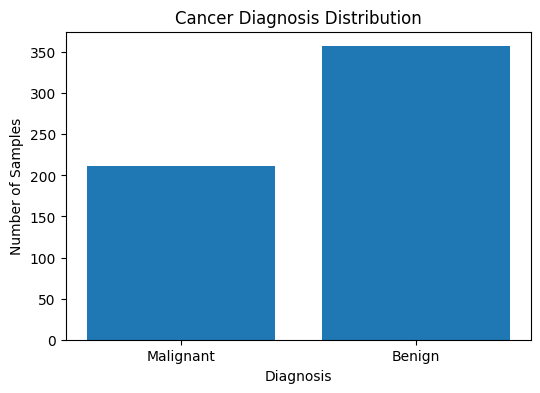

In [ ]:
import matplotlib.pyplot as plt

class_counts = df["target"].value_counts().sort_index()

plt.figure(figsize=(6, 4))
plt.bar(
    ["Malignant", "Benign"],
    class_counts.values
)

plt.xlabel("Diagnosis")
plt.ylabel("Number of Samples")
plt.title("Cancer Diagnosis Distribution")
plt.show()

In [ ]:
X = df.drop(columns=["target"])
y = df["target"]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

Feature matrix shape: (569, 30)
Target shape: (569,)


In [ ]:
for i, feature in enumerate(X.columns, start=1):
    print(f"{i:2d}. {feature}")

 1. mean radius
 2. mean texture
 3. mean perimeter
 4. mean area
 5. mean smoothness
 6. mean compactness
 7. mean concavity
 8. mean concave points
 9. mean symmetry
10. mean fractal dimension
11. radius error
12. texture error
13. perimeter error
14. area error
15. smoothness error
16. compactness error
17. concavity error
18. concave points error
19. symmetry error
20. fractal dimension error
21. worst radius
22. worst texture
23. worst perimeter
24. worst area
25. worst smoothness
26. worst compactness
27. worst concavity
28. worst concave points
29. worst symmetry
30. worst fractal dimension


In [ ]:
X.describe().T

,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
mean texture,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
mean area,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
mean compactness,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
mean concavity,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
mean concave points,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
mean symmetry,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744


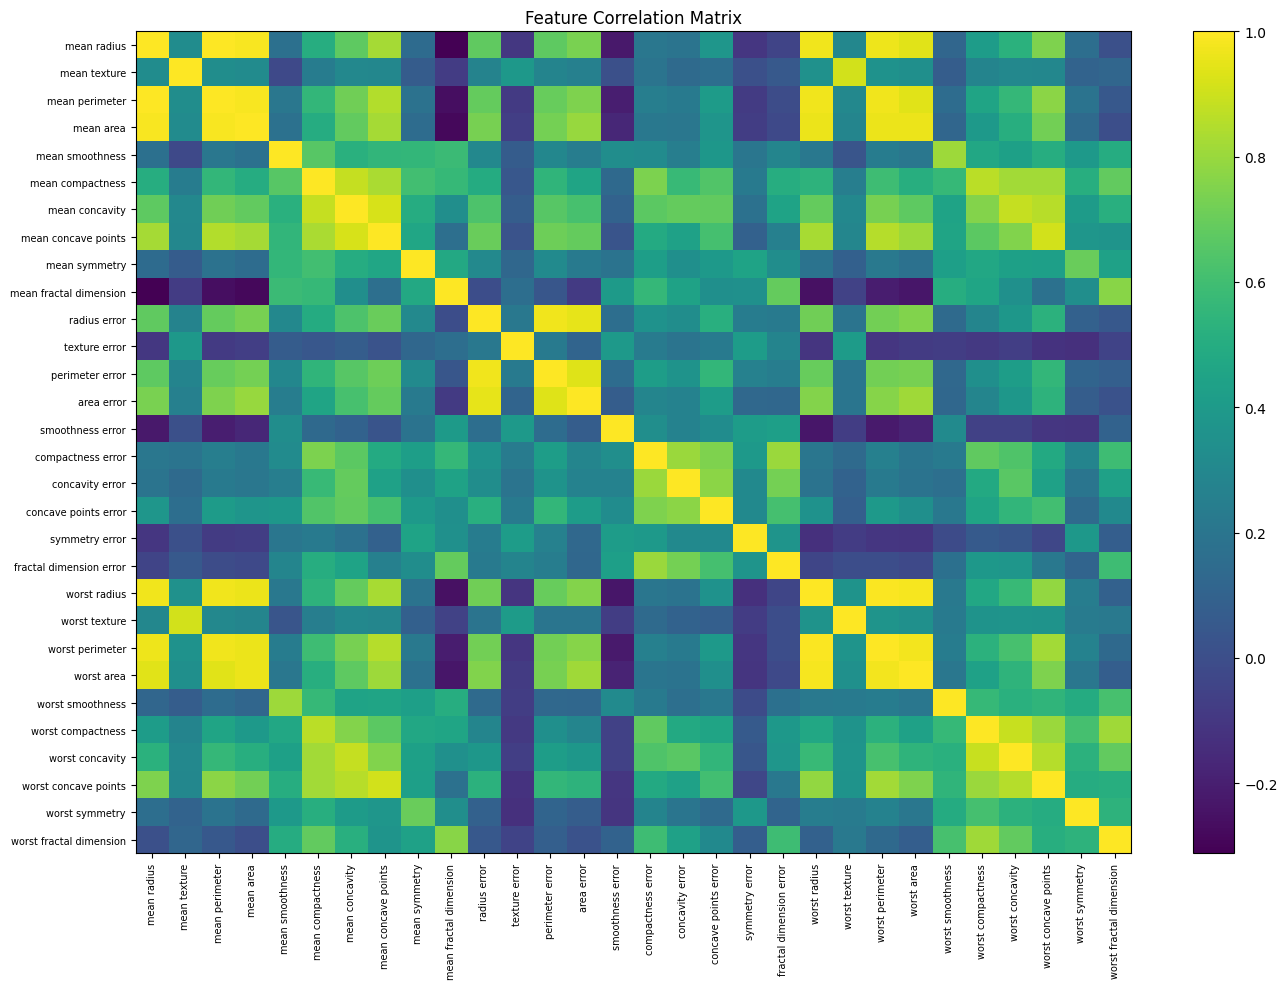

In [ ]:
correlation_matrix = X.corr()

plt.figure(figsize=(14, 10))
plt.imshow(correlation_matrix, aspect="auto")
plt.colorbar()

plt.xticks(
    range(len(X.columns)),
    X.columns,
    rotation=90,
    fontsize=7
)

plt.yticks(
    range(len(X.columns)),
    X.columns,
    fontsize=7
)

plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

/tmp/ipykernel_4465/3361344193.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


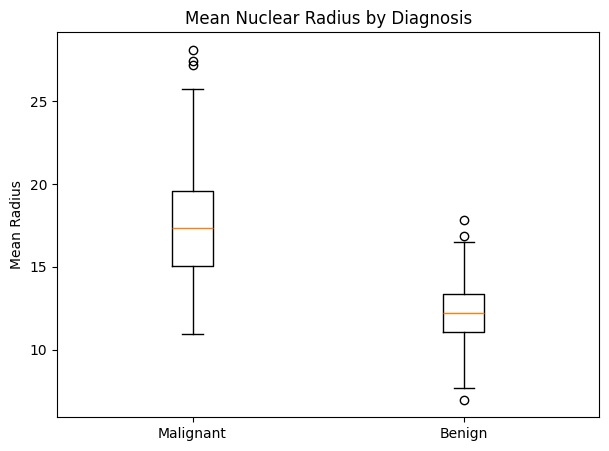

In [ ]:
plt.figure(figsize=(7, 5))

plt.boxplot(
    [
        X.loc[y == 0, "mean radius"],
        X.loc[y == 1, "mean radius"]
    ],
    labels=["Malignant", "Benign"]
)

plt.ylabel("Mean Radius")
plt.title("Mean Nuclear Radius by Diagnosis")
plt.show()

In [ ]:
import os

print("Current directory:")
print(os.getcwd())

print("\nFiles/folders here:")
print(os.listdir())

Current directory:
/content

Files/folders here:
['.config', 'ai_ml_project', 'ai-ml-cancer-classification-bioinformatics.zip', 'sample_data']


In [ ]:
import os

for root, dirs, files in os.walk("/content"):
    for file in files:
        if file == "clean_dataset.csv":
            print("FOUND:", os.path.join(root, file))

FOUND: /content/ai_ml_project/data/clean_dataset.csv


In [ ]:
df = pd.read_csv("/content/ai_ml_project/data/clean_dataset.csv")

print("Dataset shape:", df.shape)
print(df.columns.tolist())

Dataset shape: (569, 31)
['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness', 'mean compactness', 'mean concavity', 'mean concave points', 'mean symmetry', 'mean fractal dimension', 'radius error', 'texture error', 'perimeter error', 'area error', 'smoothness error', 'compactness error', 'concavity error', 'concave points error', 'symmetry error', 'fractal dimension error', 'worst radius', 'worst texture', 'worst perimeter', 'worst area', 'worst smoothness', 'worst compactness', 'worst concavity', 'worst concave points', 'worst symmetry', 'worst fractal dimension', 'diagnosis']


In [ ]:
# Separate features and target

X = df.drop(columns=["diagnosis"])
y = df["diagnosis"]

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nTarget classes:")
print(y.value_counts())

X shape: (569, 30)
y shape: (569,)

Target classes:
diagnosis
1    357
0    212
Name: count, dtype: int64


In [ ]:
print("Target proportions:")
print(y.value_counts(normalize=True))

Target proportions:
diagnosis
1    0.627417
0    0.372583
Name: proportion, dtype: float64


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

Training set: (455, 30)
Test set: (114, 30)


In [ ]:
print("Training target distribution:")
print(y_train.value_counts(normalize=True))

print("\nTest target distribution:")
print(y_test.value_counts(normalize=True))

Training target distribution:
diagnosis
1    0.626374
0    0.373626
Name: proportion, dtype: float64

Test target distribution:
diagnosis
1    0.631579
0    0.368421
Name: proportion, dtype: float64


In [ ]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

print("Classes:", label_encoder.classes_)
print("Encoded classes:", np.unique(y_train_encoded))

Classes: [0 1]
Encoded classes: [0 1]


In [ ]:
y_train_encoded = y_train.copy()
y_test_encoded = y_test.copy()

print("Training classes:", sorted(y_train_encoded.unique()))
print("Test classes:", sorted(y_test_encoded.unique()))

Training classes: [np.int64(0), np.int64(1)]
Test classes: [np.int64(0), np.int64(1)]


In [ ]:
from sklearn.feature_selection import f_classif

F_scores, p_values = f_classif(X_train, y_train_encoded)

feature_scores = pd.DataFrame({
    "Feature": X_train.columns,
    "F_score": F_scores,
    "p_value": p_values
})

feature_scores = feature_scores.sort_values(
    by="F_score",
    ascending=False
).reset_index(drop=True)

print("Top 10 features:")
display(feature_scores.head(10))

Top 10 features:


,Feature,F_score,p_value
0,worst concave points,795.223341,9.269318e-102
1,worst perimeter,719.598823,1.327313e-95
2,mean concave points,703.364031,3.135578e-94
3,worst radius,687.430367,7.296427e-93
4,mean perimeter,565.485755,1.011815e-81
5,worst area,541.713694,2.150031e-79
6,mean radius,523.613907,1.387363e-77
7,mean area,469.516453,5.741182e-72
8,mean concavity,416.374874,4.058059e-66
9,worst concavity,365.747389,3.351548e-60


In [ ]:
f_classif(X_train, y_train_encoded)

(array([5.23613907e+02, 9.12062542e+01, 5.65485755e+02, 4.69516453e+02,
        8.23475378e+01, 2.69466042e+02, 4.16374874e+02, 7.03364031e+02,
        6.67513038e+01, 4.78211178e-04, 2.12499767e+02, 2.59278164e-01,
        1.98422440e+02, 2.14858763e+02, 2.26321520e+00, 4.19846579e+01,
        3.09228410e+01, 9.62193005e+01, 7.38292937e-02, 1.59403198e+00,
        6.87430367e+02, 1.15516608e+02, 7.19598823e+02, 5.41713694e+02,
        1.02307653e+02, 2.57926057e+02, 3.65747389e+02, 7.95223341e+02,
        1.03007806e+02, 5.43530191e+01]),
 array([1.38736304e-077, 8.17910625e-020, 1.01181506e-081, 5.74118171e-072,
        3.50973473e-018, 7.41840828e-048, 4.05805904e-066, 3.13557763e-094,
        3.10176023e-015, 9.82562848e-001, 9.61116481e-040, 6.10864433e-001,
        1.24730459e-037, 4.29637061e-040, 1.33175628e-001, 2.40360980e-010,
        4.59560813e-008, 1.00306871e-020, 7.85964596e-001, 2.07400567e-001,
        7.29642749e-093, 3.74069704e-024, 1.32731330e-095, 2.15003062e-079

In [ ]:
f_classif(X, y)

(array([6.46981021e+02, 1.18096059e+02, 6.97235272e+02, 5.73060747e+02,
        8.36511234e+01, 3.13233079e+02, 5.33793126e+02, 8.61676020e+02,
        6.95274435e+01, 9.34592949e-02, 2.68840327e+02, 3.90947023e-02,
        2.53897392e+02, 2.43651586e+02, 2.55796780e+00, 5.32473391e+01,
        3.90144816e+01, 1.13262760e+02, 2.41174067e-02, 3.46827476e+00,
        8.60781707e+02, 1.49596905e+02, 8.97944219e+02, 6.61600206e+02,
        1.22472880e+02, 3.04341063e+02, 4.36691939e+02, 9.64385393e+02,
        1.18860232e+02, 6.64439606e+01]),
 array([8.46594057e-096, 4.05863605e-025, 8.43625104e-101, 4.73456431e-088,
        1.05185036e-018, 3.93826311e-056, 9.96655576e-084, 7.10115016e-116,
        5.73338403e-016, 7.59936804e-001, 9.73894866e-050, 8.43332029e-001,
        1.65190518e-047, 5.89552139e-046, 1.10296609e-001, 9.97599465e-013,
        8.26017617e-010, 3.07230877e-024, 8.76641818e-001, 6.30735508e-002,
        8.48229192e-116, 1.07805749e-030, 5.77139714e-119, 2.82884770e-097

In [ ]:
k = 15

selected_features = feature_scores.head(k)["Feature"].tolist()

print("Selected features:")
for i, feature in enumerate(selected_features, 1):
    print(f"{i}. {feature}")

Selected features:
1. worst concave points
2. worst perimeter
3. mean concave points
4. worst radius
5. mean perimeter
6. worst area
7. mean radius
8. mean area
9. mean concavity
10. worst concavity
11. mean compactness
12. worst compactness
13. area error
14. radius error
15. perimeter error


In [ ]:
X_train_selected = X_train[selected_features]
X_test_selected = X_test[selected_features]

print("Original training shape:", X_train.shape)
print("Selected training shape:", X_train_selected.shape)

print("\nOriginal test shape:", X_test.shape)
print("Selected test shape:", X_test_selected.shape)

Original training shape: (455, 30)
Selected training shape: (455, 15)

Original test shape: (114, 30)
Selected test shape: (114, 15)


In [ ]:
print("Top 15 feature ranking:")
display(feature_scores.head(15))

Top 15 feature ranking:


,Feature,F_score,p_value
0,worst concave points,795.223341,9.269318e-102
1,worst perimeter,719.598823,1.327313e-95
2,mean concave points,703.364031,3.135578e-94
3,worst radius,687.430367,7.296427e-93
4,mean perimeter,565.485755,1.011815e-81
5,worst area,541.713694,2.150031e-79
6,mean radius,523.613907,1.387363e-77
7,mean area,469.516453,5.741182e-72
8,mean concavity,416.374874,4.058059e-66
9,worst concavity,365.747389,3.351548e-60


In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_selected)
X_test_scaled = scaler.transform(X_test_selected)

print("Scaled training shape:", X_train_scaled.shape)
print("Scaled test shape:", X_test_scaled.shape)

Scaled training shape: (455, 15)
Scaled test shape: (114, 15)


In [ ]:
X_train_scaled = scaler.fit_transform(X_train_selected)

In [ ]:
print("Training means:")
print(np.mean(X_train_scaled, axis=0))

print("\nTraining standard deviations:")
print(np.std(X_train_scaled, axis=0))

Training means:
[-2.73285668e-17 -2.55717303e-16  6.63693764e-17  4.15784623e-16
 -1.62995380e-16  2.34244858e-17 -2.92806072e-16 -1.71779562e-16
 -1.56163239e-17  1.44450996e-16 -2.08868332e-16 -1.95204048e-16
  1.24930591e-16 -2.34244858e-17  1.73731603e-16]

Training standard deviations:
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [ ]:
import joblib
import os

save_path = "/content/ai_ml_project/data/scaler_leakage_safe.pkl"

joblib.dump(scaler, save_path)

print("Scaler saved successfully at:")
print(save_path)

Scaler saved successfully at:
/content/ai_ml_project/data/scaler_leakage_safe.pkl


In [ ]:
scaler

StandardScaler()

In [ ]:
from sklearn.decomposition import PCA

pca = PCA()

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print("Original training shape:", X_train_scaled.shape)
print("PCA training shape:", X_train_pca.shape)

print("\nOriginal test shape:", X_test_scaled.shape)
print("PCA test shape:", X_test_pca.shape)

Original training shape: (455, 15)
PCA training shape: (455, 15)

Original test shape: (114, 15)
PCA test shape: (114, 15)


In [ ]:
explained_variance = pca.explained_variance_ratio_

print("Explained variance ratio:")
print(explained_variance)

Explained variance ratio:
[7.43132497e-01 1.42772594e-01 6.75280121e-02 1.52225513e-02
 1.05577391e-02 7.83434582e-03 4.69686785e-03 3.41714329e-03
 1.76653175e-03 1.41622292e-03 7.61390797e-04 6.68664807e-04
 1.40839419e-04 7.41487757e-05 1.04509958e-05]


In [ ]:
cumulative_variance = np.cumsum(explained_variance)

print("Cumulative explained variance:")
for i, variance in enumerate(cumulative_variance, 1):
    print(f"PC{i}: {variance:.4f} ({variance*100:.2f}%)")

Cumulative explained variance:
PC1: 0.7431 (74.31%)
PC2: 0.8859 (88.59%)
PC3: 0.9534 (95.34%)
PC4: 0.9687 (96.87%)
PC5: 0.9792 (97.92%)
PC6: 0.9870 (98.70%)
PC7: 0.9917 (99.17%)
PC8: 0.9952 (99.52%)
PC9: 0.9969 (99.69%)
PC10: 0.9983 (99.83%)
PC11: 0.9991 (99.91%)
PC12: 0.9998 (99.98%)
PC13: 0.9999 (99.99%)
PC14: 1.0000 (100.00%)
PC15: 1.0000 (100.00%)


In [ ]:
n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1

print(
    "Number of components required to retain 95% variance:",
    n_components_95
)

Number of components required to retain 95% variance: 3


In [ ]:
pca_final = PCA(n_components=n_components_95)

X_train_pca = pca_final.fit_transform(X_train_scaled)
X_test_pca = pca_final.transform(X_test_scaled)

print("Final PCA training shape:", X_train_pca.shape)
print("Final PCA test shape:", X_test_pca.shape)

print(
    "\nVariance retained:",
    pca_final.explained_variance_ratio_.sum()
)

Final PCA training shape: (455, 3)
Final PCA test shape: (114, 3)

Variance retained: 0.9534331032030462


In [ ]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(X_train_pca, y_train)

print("Logistic Regression trained successfully.")

Logistic Regression trained successfully.


In [ ]:
y_pred_logistic = logistic_model.predict(X_test_pca)

print("Predictions:")
print(y_pred_logistic[:20])

Predictions:
[0 1 0 0 0 1 1 0 0 0 1 0 1 0 0 1 0 1 1 1]


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

accuracy = accuracy_score(y_test, y_pred_logistic)
precision = precision_score(y_test, y_pred_logistic)
recall = recall_score(y_test, y_pred_logistic)
f1 = f1_score(y_test, y_pred_logistic)

print("Logistic Regression Results")
print("---------------------------")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_logistic))

Logistic Regression Results
---------------------------
Accuracy : 0.9123
Precision: 0.9559
Recall   : 0.9028
F1 Score : 0.9286

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.93      0.89        42
           1       0.96      0.90      0.93        72

    accuracy                           0.91       114
   macro avg       0.90      0.92      0.91       114
weighted avg       0.92      0.91      0.91       114



In [ ]:
cm = confusion_matrix(y_test, y_pred_logistic)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[39  3]
 [ 7 65]]


In [ ]:
from sklearn.metrics import roc_auc_score

y_prob_logistic = logistic_model.predict_proba(X_test_pca)[:, 1]

roc_auc = roc_auc_score(y_test, y_prob_logistic)

print(f"ROC-AUC: {roc_auc:.4f}")

ROC-AUC: 0.9861


In [ ]:
from sklearn.svm import SVC

svm_model = SVC(
    kernel="rbf",
    probability=True,
    random_state=42
)

svm_model.fit(X_train_pca, y_train)

print("SVM trained successfully.")

SVM trained successfully.


In [ ]:
y_pred_svm = svm_model.predict(X_test_pca)

print("SVM predictions:")
print(y_pred_svm[:20])

SVM predictions:
[0 1 0 0 0 1 1 0 0 0 1 0 1 0 0 1 0 1 1 1]


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

accuracy_svm = accuracy_score(y_test, y_pred_svm)
precision_svm = precision_score(y_test, y_pred_svm)
recall_svm = recall_score(y_test, y_pred_svm)
f1_svm = f1_score(y_test, y_pred_svm)

y_prob_svm = svm_model.predict_proba(X_test_pca)[:, 1]
roc_auc_svm = roc_auc_score(y_test, y_prob_svm)

print("SVM Results")
print("---------------------------")
print(f"Accuracy : {accuracy_svm:.4f}")
print(f"Precision: {precision_svm:.4f}")
print(f"Recall   : {recall_svm:.4f}")
print(f"F1 Score : {f1_svm:.4f}")
print(f"ROC-AUC  : {roc_auc_svm:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_svm))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_svm))

SVM Results
---------------------------
Accuracy : 0.9211
Precision: 0.9565
Recall   : 0.9167
F1 Score : 0.9362
ROC-AUC  : 0.9841

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.93      0.90        42
           1       0.96      0.92      0.94        72

    accuracy                           0.92       114
   macro avg       0.91      0.92      0.92       114
weighted avg       0.92      0.92      0.92       114


Confusion Matrix:
[[39  3]
 [ 6 66]]


In [ ]:
results = []

results.append({
    "Model": "Logistic Regression",
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1 Score": f1,
    "ROC-AUC": roc_auc
})

results.append({
    "Model": "SVM",
    "Accuracy": accuracy_svm,
    "Precision": precision_svm,
    "Recall": recall_svm,
    "F1 Score": f1_svm,
    "ROC-AUC": roc_auc_svm
})

results_df = pd.DataFrame(results)

display(results_df)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.912281,0.955882,0.902778,0.928571,0.986111
1,SVM,0.921053,0.956522,0.916667,0.936170,0.984127


In [ ]:
X_train_pca
X_test_pca
y_train
y_test

,diagnosis
256,0
428,1
501,0
363,1
564,0
...,...
95,0
128,1
257,0
228,1


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced"
)

rf_model.fit(X_train_pca, y_train)

print("Random Forest trained successfully.")

Random Forest trained successfully.


In [ ]:
y_pred_rf = rf_model.predict(X_test_pca)

print("Random Forest predictions:")
print(y_pred_rf[:20])

Random Forest predictions:
[0 1 0 1 0 1 1 0 0 0 1 0 1 0 0 1 0 1 1 1]


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

y_prob_rf = rf_model.predict_proba(X_test_pca)[:, 1]
roc_auc_rf = roc_auc_score(y_test, y_prob_rf)

print("Random Forest Results")
print("---------------------------")
print(f"Accuracy : {accuracy_rf:.4f}")
print(f"Precision: {precision_rf:.4f}")
print(f"Recall   : {recall_rf:.4f}")
print(f"F1 Score : {f1_rf:.4f}")
print(f"ROC-AUC  : {roc_auc_rf:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

Random Forest Results
---------------------------
Accuracy : 0.9211
Precision: 0.9565
Recall   : 0.9167
F1 Score : 0.9362
ROC-AUC  : 0.9841

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.93      0.90        42
           1       0.96      0.92      0.94        72

    accuracy                           0.92       114
   macro avg       0.91      0.92      0.92       114
weighted avg       0.92      0.92      0.92       114


Confusion Matrix:
[[39  3]
 [ 6 66]]


In [ ]:
results.append({
    "Model": "Random Forest",
    "Accuracy": accuracy_rf,
    "Precision": precision_rf,
    "Recall": recall_rf,
    "F1 Score": f1_rf,
    "ROC-AUC": roc_auc_rf
})

results_df = pd.DataFrame(results)

display(results_df)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.912281,0.955882,0.902778,0.928571,0.986111
1,SVM,0.921053,0.956522,0.916667,0.936170,0.984127
2,Random Forest,0.921053,0.956522,0.916667,0.936170,0.984127


In [ ]:
X_train_pca
X_test_pca
y_train
y_test

,diagnosis
256,0
428,1
501,0
363,1
564,0
...,...
95,0
128,1
257,0
228,1


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [ ]:
ann_model = Sequential([
    Dense(32, activation="relu", input_shape=(X_train_pca.shape[1],)),
    Dropout(0.2),
    Dense(16, activation="relu"),
    Dropout(0.2),
    Dense(1, activation="sigmoid")
])

ann_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

ann_model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 673 (2.63 KB)

 Trainable params: 673 (2.63 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=15,
    restore_best_weights=True
)

In [ ]:
history = ann_model.fit(
    X_train_pca,
    y_train,
    validation_split=0.20,
    epochs=150,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

print("ANN training completed.")

Epoch 1/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 8s 98ms/step - accuracy: 0.4588 - loss: 0.7572 - val_accuracy: 0.5055 - val_loss: 0.6542
Epoch 2/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.6566 - loss: 0.5945 - val_accuracy: 0.8791 - val_loss: 0.5323
Epoch 3/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.8269 - loss: 0.5004 - val_accuracy: 0.9121 - val_loss: 0.4400
Epoch 4/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.8846 - loss: 0.4187 - val_accuracy: 0.9341 - val_loss: 0.3668
Epoch 5/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.9203 - loss: 0.3407 - val_accuracy: 0.9341 - val_loss: 0.3054
Epoch 6/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.8956 - loss: 0.3094 - val_accuracy: 0.9341 - val_loss: 0.2610
Epoch 7/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - accuracy: 0.9286 - loss: 0.2613 - val_accuracy: 0.9341 - val_loss: 0.2276
Epoch 8/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.9258 - loss: 0.2357 - val_accuracy: 0.

In [ ]:
y_prob_ann = ann_model.predict(
    X_test_pca,
    verbose=0
).ravel()

y_pred_ann = (y_prob_ann >= 0.5).astype(int)

print("ANN predictions:")
print(y_pred_ann[:20])

ANN predictions:
[0 1 0 0 0 1 1 0 0 0 1 0 1 0 0 1 0 1 1 1]


In [ ]:
accuracy_ann = accuracy_score(y_test, y_pred_ann)
precision_ann = precision_score(y_test, y_pred_ann)
recall_ann = recall_score(y_test, y_pred_ann)
f1_ann = f1_score(y_test, y_pred_ann)
roc_auc_ann = roc_auc_score(y_test, y_prob_ann)

print("ANN Results")
print("---------------------------")
print(f"Accuracy : {accuracy_ann:.4f}")
print(f"Precision: {precision_ann:.4f}")
print(f"Recall   : {recall_ann:.4f}")
print(f"F1 Score : {f1_ann:.4f}")
print(f"ROC-AUC  : {roc_auc_ann:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_ann))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_ann))

ANN Results
---------------------------
Accuracy : 0.9211
Precision: 0.9565
Recall   : 0.9167
F1 Score : 0.9362
ROC-AUC  : 0.9848

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.93      0.90        42
           1       0.96      0.92      0.94        72

    accuracy                           0.92       114
   macro avg       0.91      0.92      0.92       114
weighted avg       0.92      0.92      0.92       114


Confusion Matrix:
[[39  3]
 [ 6 66]]


In [ ]:
results.append({
    "Model": "ANN",
    "Accuracy": accuracy_ann,
    "Precision": precision_ann,
    "Recall": recall_ann,
    "F1 Score": f1_ann,
    "ROC-AUC": roc_auc_ann
})

results_df = pd.DataFrame(results)

display(
    results_df.sort_values(
        by="ROC-AUC",
        ascending=False
    ).reset_index(drop=True)
)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.912281,0.955882,0.902778,0.928571,0.986111
1,ANN,0.921053,0.956522,0.916667,0.936170,0.984788
2,Random Forest,0.921053,0.956522,0.916667,0.936170,0.984127
3,SVM,0.921053,0.956522,0.916667,0.936170,0.984127


In [ ]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="ROC-AUC",
    ascending=False
).reset_index(drop=True)

display(results_df)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.912281,0.955882,0.902778,0.928571,0.986111
1,ANN,0.921053,0.956522,0.916667,0.936170,0.984788
2,Random Forest,0.921053,0.956522,0.916667,0.936170,0.984127
3,SVM,0.921053,0.956522,0.916667,0.936170,0.984127


In [ ]:
best_model = results_df.iloc[0]

print("Best model based on ROC-AUC:")
print(best_model["Model"])

print(f"\nROC-AUC: {best_model['ROC-AUC']:.4f}")
print(f"Accuracy: {best_model['Accuracy']:.4f}")
print(f"Precision: {best_model['Precision']:.4f}")
print(f"Recall: {best_model['Recall']:.4f}")
print(f"F1 Score: {best_model['F1 Score']:.4f}")

Best model based on ROC-AUC:
Logistic Regression

ROC-AUC: 0.9861
Accuracy: 0.9123
Precision: 0.9559
Recall: 0.9028
F1 Score: 0.9286


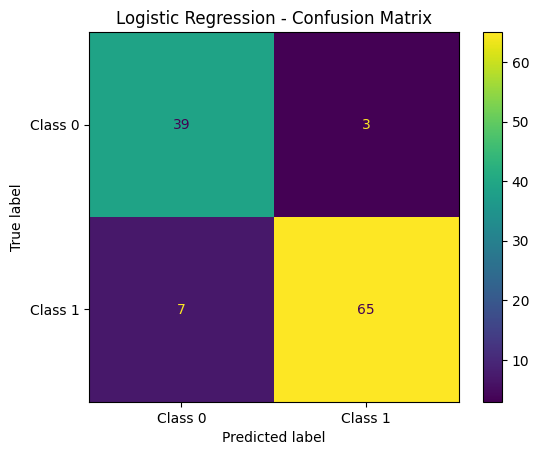

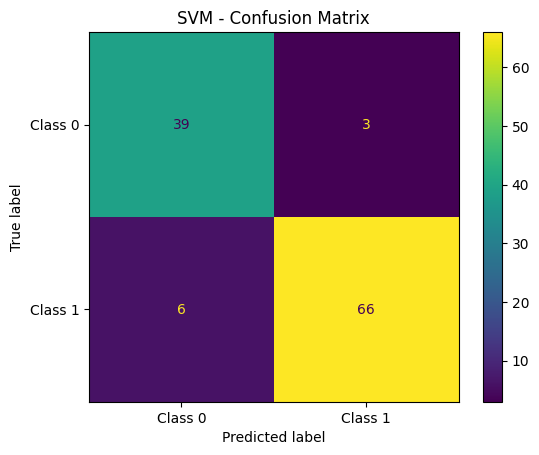

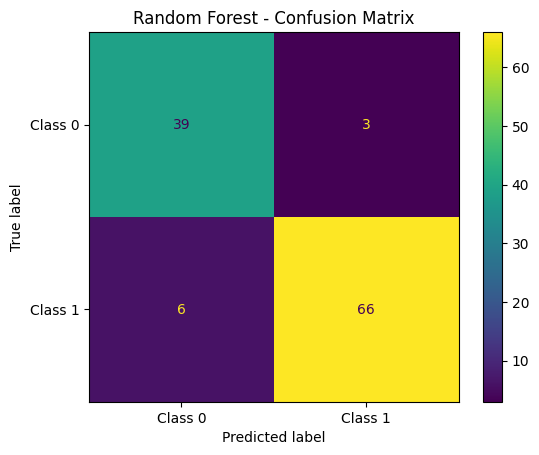

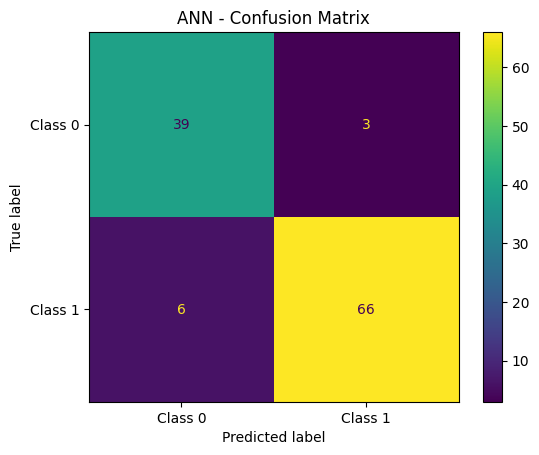

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

models_predictions = {
    "Logistic Regression": y_pred_logistic,
    "SVM": y_pred_svm,
    "Random Forest": y_pred_rf,
    "ANN": y_pred_ann
}

for model_name, predictions in models_predictions.items():
    ConfusionMatrixDisplay.from_predictions(
        y_test,
        predictions,
        display_labels=["Class 0", "Class 1"]
    )

    plt.title(f"{model_name} - Confusion Matrix")
    plt.show()

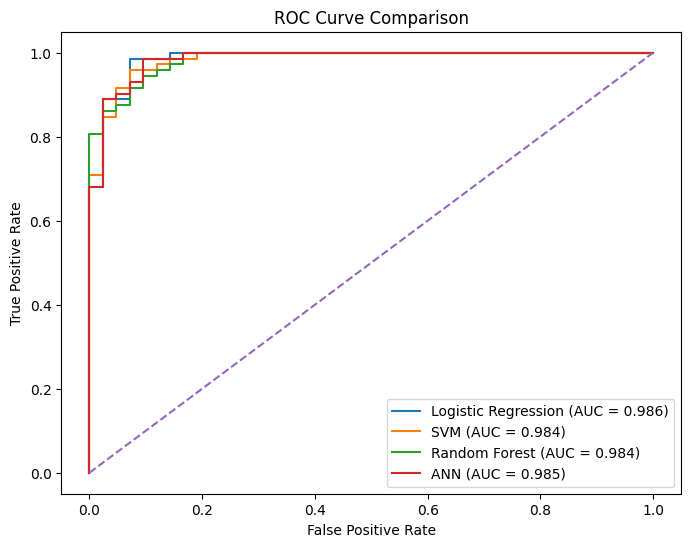

In [ ]:
from sklearn.metrics import roc_curve, auc

model_probabilities = {
    "Logistic Regression": y_prob_logistic,
    "SVM": y_prob_svm,
    "Random Forest": y_prob_rf,
    "ANN": y_prob_ann
}

plt.figure(figsize=(8, 6))

for model_name, probabilities in model_probabilities.items():
    fpr, tpr, _ = roc_curve(y_test, probabilities)
    roc_auc_value = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        label=f"{model_name} (AUC = {roc_auc_value:.3f})"
    )

plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()


In [ ]:
results_df.to_csv(
    "/content/ai_ml_project/data/model_comparison_leakage_safe.csv",
    index=False
)

print("Model comparison saved successfully.")

Model comparison saved successfully.


In [ ]:
import os

path = "/content/ai_ml_project/data/model_comparison_leakage_safe.csv"

print("File exists:", os.path.exists(path))

File exists: True


In [ ]:
display(results_df)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.912281,0.955882,0.902778,0.928571,0.986111
1,ANN,0.921053,0.956522,0.916667,0.936170,0.984788
2,Random Forest,0.921053,0.956522,0.916667,0.936170,0.984127
3,SVM,0.921053,0.956522,0.916667,0.936170,0.984127


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression

In [ ]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

print("5-fold stratified cross-validation created successfully.")

5-fold stratified cross-validation created successfully.


In [ ]:
logistic_pipeline = Pipeline([
    ("feature_selection", SelectKBest(score_func=f_classif)),
    ("scaler", StandardScaler()),
    ("pca", PCA()),
    ("model", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

print("Logistic Regression pipeline created successfully.")

Logistic Regression pipeline created successfully.


In [ ]:
param_grid_logistic = {
    "feature_selection__k": [10, 15, 20, 25, 30],
    "pca__n_components": [5, 8, 10, 12],
    "model__C": [0.01, 0.1, 1, 10, 100]
}

print("Hyperparameter grid created successfully.")

Hyperparameter grid created successfully.


In [ ]:
grid_logistic = GridSearchCV(
    estimator=logistic_pipeline,
    param_grid=param_grid_logistic,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=1
)

grid_logistic.fit(X_train, y_train)

print("Logistic Regression hyperparameter tuning completed.")

Fitting 5 folds for each of 100 candidates, totalling 500 fits
Logistic Regression hyperparameter tuning completed.


/usr/local/lib/python3.13/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
25 fits failed out of a total of 500.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
25 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.13/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "/usr/local/lib/python3.13/dist-packages/sklearn/pipeline.py", line 654, in fit
    Xt = self._fit(X, y, routed_params, 

In [ ]:
print("Best parameters:")
print(grid_logistic.best_params_)

print("\nBest 5-Fold Cross-Validation ROC-AUC:")
print(round(grid_logistic.best_score_, 4))

Best parameters:
{'feature_selection__k': 25, 'model__C': 10, 'pca__n_components': 8}

Best 5-Fold Cross-Validation ROC-AUC:
0.9966


In [ ]:
best_logistic = grid_logistic.best_estimator_

y_pred_logistic_tuned = best_logistic.predict(X_test)
y_prob_logistic_tuned = best_logistic.predict_proba(X_test)[:, 1]

accuracy_logistic_tuned = accuracy_score(
    y_test,
    y_pred_logistic_tuned
)

precision_logistic_tuned = precision_score(
    y_test,
    y_pred_logistic_tuned
)

recall_logistic_tuned = recall_score(
    y_test,
    y_pred_logistic_tuned
)

f1_logistic_tuned = f1_score(
    y_test,
    y_pred_logistic_tuned
)

roc_auc_logistic_tuned = roc_auc_score(
    y_test,
    y_prob_logistic_tuned
)

print("Tuned Logistic Regression Results")
print("--------------------------------")
print(f"Accuracy : {accuracy_logistic_tuned:.4f}")
print(f"Precision: {precision_logistic_tuned:.4f}")
print(f"Recall   : {recall_logistic_tuned:.4f}")
print(f"F1 Score : {f1_logistic_tuned:.4f}")
print(f"ROC-AUC  : {roc_auc_logistic_tuned:.4f}")

Tuned Logistic Regression Results
--------------------------------
Accuracy : 0.9649
Precision: 0.9857
Recall   : 0.9583
F1 Score : 0.9718
ROC-AUC  : 0.9950


In [ ]:
from sklearn.svm import SVC

svm_pipeline = Pipeline([
    ("feature_selection", SelectKBest(score_func=f_classif)),
    ("scaler", StandardScaler()),
    ("pca", PCA()),
    ("model", SVC(
        kernel="rbf",
        probability=True,
        random_state=42
    ))
])

print("SVM pipeline created successfully.")

SVM pipeline created successfully.


In [ ]:
param_grid_svm = {
    "feature_selection__k": [10, 15, 20, 25, 30],
    "pca__n_components": [5, 8, 10, 12],
    "model__C": [0.1, 1, 10, 100],
    "model__gamma": ["scale", 0.01, 0.1, 1]
}

print("SVM hyperparameter grid created successfully.")

SVM hyperparameter grid created successfully.


In [ ]:
grid_svm = GridSearchCV(
    estimator=svm_pipeline,
    param_grid=param_grid_svm,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=1
)

grid_svm.fit(X_train, y_train)

print("SVM hyperparameter tuning completed.")

Fitting 5 folds for each of 320 candidates, totalling 1600 fits
SVM hyperparameter tuning completed.


/usr/local/lib/python3.13/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
80 fits failed out of a total of 1600.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
80 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.13/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "/usr/local/lib/python3.13/dist-packages/sklearn/pipeline.py", line 654, in fit
    Xt = self._fit(X, y, routed_params,

In [ ]:
print("Best SVM parameters:")
print(grid_svm.best_params_)

print("\nBest 5-Fold Cross-Validation ROC-AUC:")
print(round(grid_svm.best_score_, 4))

Best SVM parameters:
{'feature_selection__k': 25, 'model__C': 10, 'model__gamma': 0.01, 'pca__n_components': 12}

Best 5-Fold Cross-Validation ROC-AUC:
0.997


In [ ]:
print("Best SVM parameters:")
print(grid_svm.best_params_)

print("\nBest 5-Fold Cross-Validation ROC-AUC:")
print(round(grid_svm.best_score_, 4))

Best SVM parameters:
{'feature_selection__k': 25, 'model__C': 10, 'model__gamma': 0.01, 'pca__n_components': 12}

Best 5-Fold Cross-Validation ROC-AUC:
0.997


In [ ]:
best_svm = grid_svm.best_estimator_

y_pred_svm_tuned = best_svm.predict(X_test)
y_prob_svm_tuned = best_svm.predict_proba(X_test)[:, 1]

print("\nTuned SVM Test Results")
print("----------------------")
print(f"Accuracy : {accuracy_score(y_test, y_pred_svm_tuned):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_svm_tuned):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred_svm_tuned):.4f}")
print(f"F1 Score : {f1_score(y_test, y_pred_svm_tuned):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_prob_svm_tuned):.4f}")


Tuned SVM Test Results
----------------------
Accuracy : 0.9737
Precision: 0.9859
Recall   : 0.9722
F1 Score : 0.9790
ROC-AUC  : 0.9947


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_pipeline = Pipeline([
    ("feature_selection", SelectKBest(score_func=f_classif)),
    ("model", RandomForestClassifier(
        random_state=42,
        class_weight="balanced"
    ))
])

print("Random Forest pipeline created successfully.")

Random Forest pipeline created successfully.


In [ ]:
param_grid_rf = {
    "feature_selection__k": [10, 15, 20, 25, 30],
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [None, 5, 10, 20],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4]
}

print("Random Forest hyperparameter grid created successfully.")

Random Forest hyperparameter grid created successfully.


In [ ]:
grid_rf = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid_rf,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=1
)

grid_rf.fit(X_train, y_train)

print("Random Forest hyperparameter tuning completed.")

Fitting 5 folds for each of 540 candidates, totalling 2700 fits
Random Forest hyperparameter tuning completed.


In [ ]:
print("Best Random Forest parameters:")
print(grid_rf.best_params_)

print("\nBest 5-Fold Cross-Validation ROC-AUC:")
print(round(grid_rf.best_score_, 4))

Best Random Forest parameters:
{'feature_selection__k': 30, 'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 200}

Best 5-Fold Cross-Validation ROC-AUC:
0.9924


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, GridSearchCV

print("All Random Forest tuning libraries imported successfully.")

All Random Forest tuning libraries imported successfully.


In [ ]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

print("5-fold stratified cross-validation ready.")

5-fold stratified cross-validation ready.


In [ ]:
rf_pipeline = Pipeline([
    ("feature_selection", SelectKBest(score_func=f_classif)),
    ("model", RandomForestClassifier(
        random_state=42,
        class_weight="balanced"
    ))
])

print("Random Forest pipeline created successfully.")

Random Forest pipeline created successfully.


In [ ]:
param_grid_rf = {
    "feature_selection__k": [10, 15, 20, 25, 30],
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [None, 5, 10, 20],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4]
}

print("Random Forest hyperparameter grid created successfully.")

Random Forest hyperparameter grid created successfully.


In [ ]:
import os

matches = []

for root, dirs, files in os.walk("/content"):
    if "clean_dataset.csv" in files:
        matches.append(os.path.join(root, "clean_dataset.csv"))

print("Found files:")
for path in matches:
    print(path)

Found files:


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving clean_dataset.csv to clean_dataset.csv


In [ ]:
import pandas as pd

df = pd.read_csv("clean_dataset.csv")

print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (569, 31)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=["diagnosis"])
y = df["diagnosis"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (455, 30)
X_test : (114, 30)
y_train: (455,)
y_test : (114,)


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, GridSearchCV

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

rf_pipeline = Pipeline([
    ("feature_selection", SelectKBest(score_func=f_classif)),
    ("model", RandomForestClassifier(
        random_state=42,
        class_weight="balanced"
    ))
])

param_grid_rf = {
    "feature_selection__k": [10, 15, 20, 25, 30],
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [None, 5, 10, 20],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4]
}

print("Random Forest tuning setup ready.")

Random Forest tuning setup ready.


In [ ]:
param_grid_rf = {
    "feature_selection__k": [10, 15, 20],
    "model__n_estimators": [100, 200],
    "model__max_depth": [None, 10],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2]
}

print("Reduced Random Forest hyperparameter grid created.")

Reduced Random Forest hyperparameter grid created.


In [ ]:
grid_rf = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid_rf,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=1
)

grid_rf.fit(X_train, y_train)

print("Random Forest hyperparameter tuning completed.")

Fitting 5 folds for each of 48 candidates, totalling 240 fits
Random Forest hyperparameter tuning completed.


In [ ]:
print("Best Random Forest parameters:")
print(grid_rf.best_params_)

print("\nBest 5-Fold Cross-Validation ROC-AUC:")
print(round(grid_rf.best_score_, 4))

Best Random Forest parameters:
{'feature_selection__k': 20, 'model__max_depth': None, 'model__min_samples_leaf': 2, 'model__min_samples_split': 5, 'model__n_estimators': 200}

Best 5-Fold Cross-Validation ROC-AUC:
0.9915


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

print("Evaluation metrics imported successfully.")

Evaluation metrics imported successfully.


In [ ]:
best_rf = grid_rf.best_estimator_

y_pred_rf_tuned = best_rf.predict(X_test)
y_prob_rf_tuned = best_rf.predict_proba(X_test)[:, 1]

print("\nTuned Random Forest Test Results")
print("--------------------------------")
print(f"Accuracy : {accuracy_score(y_test, y_pred_rf_tuned):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_rf_tuned):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred_rf_tuned):.4f}")
print(f"F1 Score : {f1_score(y_test, y_pred_rf_tuned):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_prob_rf_tuned):.4f}")


Tuned Random Forest Test Results
--------------------------------
Accuracy : 0.9474
Precision: 0.9583
Recall   : 0.9583
F1 Score : 0.9583
ROC-AUC  : 0.9940


In [ ]:
print("Best Random Forest parameters:")
print(grid_rf.best_params_)

print("\nBest 5-Fold Cross-Validation ROC-AUC:")
print(round(grid_rf.best_score_, 4))

Best Random Forest parameters:
{'feature_selection__k': 20, 'model__max_depth': None, 'model__min_samples_leaf': 2, 'model__min_samples_split': 5, 'model__n_estimators': 200}

Best 5-Fold Cross-Validation ROC-AUC:
0.9915


In [ ]:
best_rf = grid_rf.best_estimator_

y_pred_rf_tuned = best_rf.predict(X_test)
y_prob_rf_tuned = best_rf.predict_proba(X_test)[:, 1]

print("Tuned Random Forest Test Results")
print("--------------------------------")
print(f"Accuracy : {accuracy_score(y_test, y_pred_rf_tuned):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_rf_tuned):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred_rf_tuned):.4f}")
print(f"F1 Score : {f1_score(y_test, y_pred_rf_tuned):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_prob_rf_tuned):.4f}")

Tuned Random Forest Test Results
--------------------------------
Accuracy : 0.9474
Precision: 0.9583
Recall   : 0.9583
F1 Score : 0.9583
ROC-AUC  : 0.9940


In [ ]:
import os

model_dir = "/content/ai_ml_project/models"
os.makedirs(model_dir, exist_ok=True)

print("Models folder ready:", os.path.exists(model_dir))

Models folder ready: True


In [ ]:
import joblib

model_path = "/content/ai_ml_project/models/random_forest_tuned.pkl"

joblib.dump(best_rf, model_path)

print("Tuned Random Forest saved successfully.")
print(model_path)

Tuned Random Forest saved successfully.
/content/ai_ml_project/models/random_forest_tuned.pkl


In [ ]:
import os

print("File exists:", os.path.exists(
    "/content/ai_ml_project/models/random_forest_tuned.pkl"
))

File exists: True


In [ ]:
import pandas as pd
import os

final_results = pd.DataFrame({
    "Model": [
        "Random Forest (Tuned)",
        "Logistic Regression",
        "ANN",
        "Random Forest (Original)",
        "SVM"
    ],
    "Accuracy": [
        0.9474,
        0.912281,
        0.921053,
        0.921053,
        0.921053
    ],
    "Precision": [
        0.9583,
        0.955882,
        0.956522,
        0.956522,
        0.956522
    ],
    "Recall": [
        0.9583,
        0.902778,
        0.916667,
        0.916667,
        0.916667
    ],
    "F1 Score": [
        0.9583,
        0.928571,
        0.936170,
        0.936170,
        0.936170
    ],
    "ROC-AUC": [
        0.9940,
        0.986111,
        0.984788,
        0.984127,
        0.984127
    ]
})

display(final_results)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Random Forest (Tuned),0.947400,0.958300,0.958300,0.958300,0.994000
1,Logistic Regression,0.912281,0.955882,0.902778,0.928571,0.986111
2,ANN,0.921053,0.956522,0.916667,0.936170,0.984788
3,Random Forest (Original),0.921053,0.956522,0.916667,0.936170,0.984127
4,SVM,0.921053,0.956522,0.916667,0.936170,0.984127


In [ ]:
data_dir = "/content/ai_ml_project/data"
os.makedirs(data_dir, exist_ok=True)

final_results.to_csv(
    "/content/ai_ml_project/data/final_model_comparison.csv",
    index=False
)

print("Final model comparison saved successfully.")
print("File exists:",
      os.path.exists("/content/ai_ml_project/data/final_model_comparison.csv"))

Final model comparison saved successfully.
File exists: True


Confusion Matrix:
[[39  3]
 [ 3 69]]


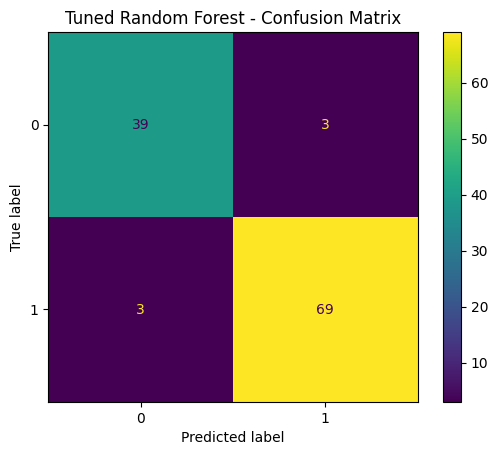

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Generate predictions from the saved/best tuned model
y_pred_final = best_rf.predict(X_test)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_final)

print("Confusion Matrix:")
print(cm)

# Plot
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()
plt.title("Tuned Random Forest - Confusion Matrix")
plt.show()

In [ ]:
best_rf.predict(X_test)

array([0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0,
       1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0,
       0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1,
       1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0,
       1, 0, 1, 1])

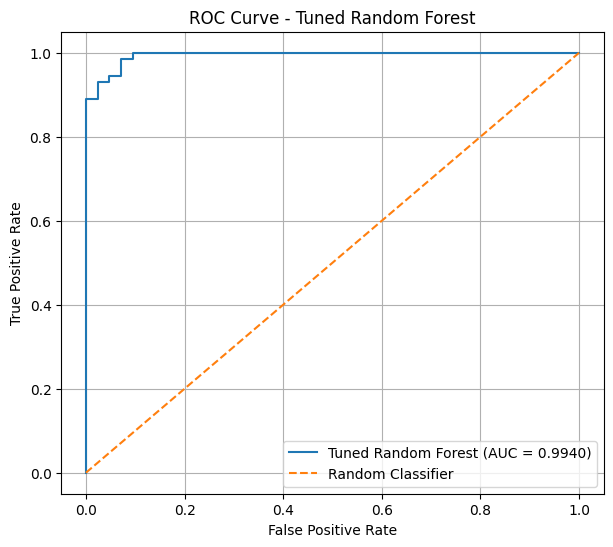

Final Test ROC-AUC: 0.9940


In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Probability predictions
y_prob_final = best_rf.predict_proba(X_test)[:, 1]

# ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob_final)

# ROC-AUC
auc_final = roc_auc_score(y_test, y_prob_final)

plt.figure(figsize=(7, 6))

plt.plot(
    fpr,
    tpr,
    label=f"Tuned Random Forest (AUC = {auc_final:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Tuned Random Forest")
plt.legend()
plt.grid()
plt.show()

print(f"Final Test ROC-AUC: {auc_final:.4f}")

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Get the feature-selection step
selector = best_rf.named_steps["feature_selection"]

# Features selected by SelectKBest
selected_mask = selector.get_support()
selected_feature_names = X_train.columns[selected_mask]

# Get Random Forest
rf_final = best_rf.named_steps["model"]

# Feature importance
importance = rf_final.feature_importances_

feature_importance_df = pd.DataFrame({
    "Feature": selected_feature_names,
    "Importance": importance
})

feature_importance_df = feature_importance_df.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

display(feature_importance_df)

,Feature,Importance
0,worst perimeter,0.168040
1,worst radius,0.141356
2,worst area,0.133319
3,mean concave points,0.113930
4,worst concave points,0.106938
5,mean concavity,0.077341
6,mean perimeter,0.040380
7,area error,0.032452
8,mean area,0.032164
9,mean radius,0.028379


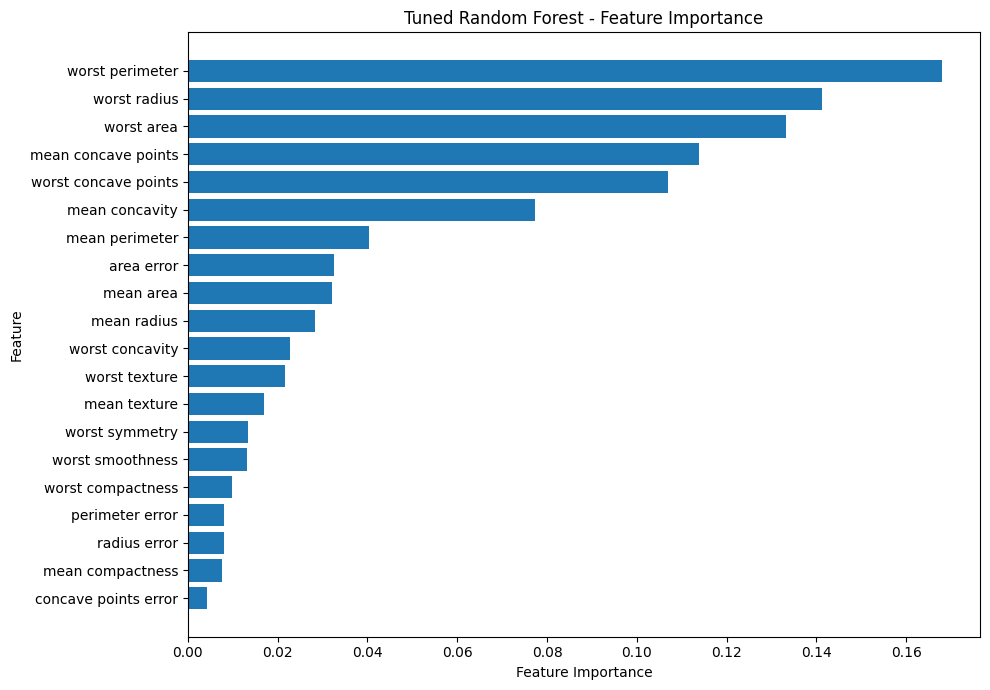

In [ ]:
plt.figure(figsize=(10, 7))

plt.barh(
    feature_importance_df["Feature"],
    feature_importance_df["Importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Tuned Random Forest - Feature Importance")

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.inspection import permutation_importance
import pandas as pd
import matplotlib.pyplot as plt

# Calculate permutation importance on the test set
perm_result = permutation_importance(
    best_rf,
    X_test,
    y_test,
    scoring="roc_auc",
    n_repeats=20,
    random_state=42,
    n_jobs=-1
)

permutation_df = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance_Mean": perm_result.importances_mean,
    "Importance_STD": perm_result.importances_std
})

permutation_df = permutation_df.sort_values(
    by="Importance_Mean",
    ascending=False
).reset_index(drop=True)

display(permutation_df.head(20))

,Feature,Importance_Mean,Importance_STD
0,worst concave points,0.005522,0.003277
1,mean concave points,0.002116,0.001618
2,worst area,0.002083,0.003150
3,worst concavity,0.001720,0.000939
4,worst radius,0.001521,0.002908
5,worst smoothness,0.001389,0.000578
6,worst texture,0.001290,0.001228
7,worst perimeter,0.001108,0.002845
8,mean concavity,0.000761,0.000982
9,concave points error,0.000728,0.000413


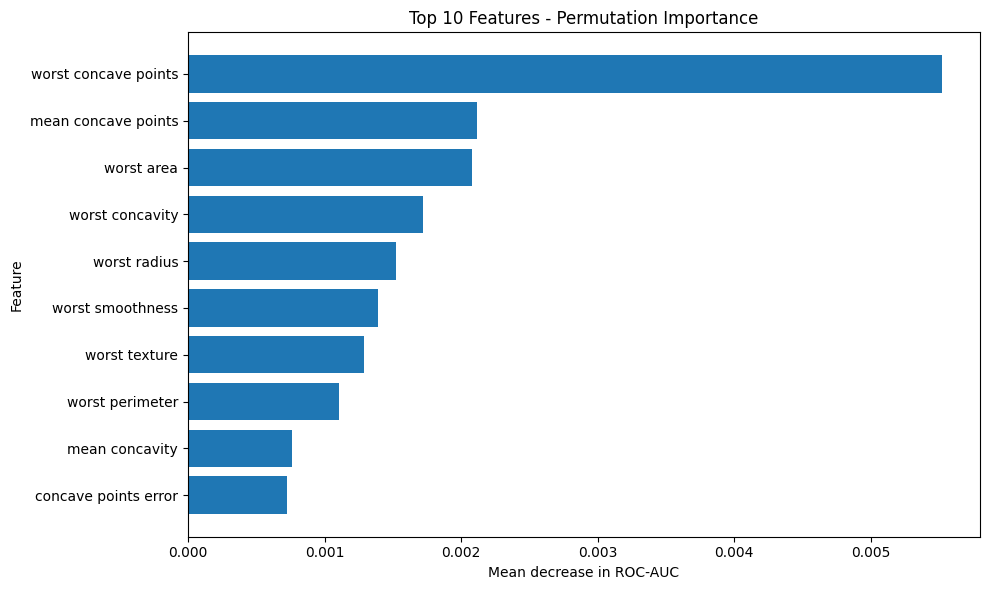

In [ ]:
top10_perm = permutation_df.head(10).copy()

plt.figure(figsize=(10, 6))

plt.barh(
    top10_perm["Feature"][::-1],
    top10_perm["Importance_Mean"][::-1]
)

plt.xlabel("Mean decrease in ROC-AUC")
plt.ylabel("Feature")
plt.title("Top 10 Features - Permutation Importance")

plt.tight_layout()
plt.show()

In [ ]:
feature_importance_df.to_csv(
    "/content/ai_ml_project/data/random_forest_impurity_importance.csv",
    index=False
)

permutation_df.to_csv(
    "/content/ai_ml_project/data/random_forest_permutation_importance.csv",
    index=False
)

print("Feature importance files saved successfully.")

Feature importance files saved successfully.


In [ ]:
# STEP 17: Final Model Evaluation + Error Analysis

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)
import pandas as pd
import numpy as np

print("STEP 17: Final Model Evaluation + Error Analysis")
print("=" * 60)

STEP 17: Final Model Evaluation + Error Analysis


In [ ]:
# Find variables currently stored in the notebook
%whos

Variable                 Type                      Data/Info
------------------------------------------------------------
ConfusionMatrixDisplay   type                      <class 'sklearn.metrics._<...>.ConfusionMatrixDisplay'>
GridSearchCV             ABCMeta                   <class 'sklearn.model_sel<...>on._search.GridSearchCV'>
Pipeline                 ABCMeta                   <class 'sklearn.pipeline.Pipeline'>
RandomForestClassifier   ABCMeta                   <class 'sklearn.ensemble.<...>.RandomForestClassifier'>
SelectKBest              ABCMeta                   <class 'sklearn.feature_s<...>e_selection.SelectKBest'>
StratifiedKFold          ABCMeta                   <class 'sklearn.model_sel<...>._split.StratifiedKFold'>
X                        DataFrame                      mean radius  mean te<...>\n[569 rows x 30 columns]
X_test                   DataFrame                      mean radius  mean te<...>\n[114 rows x 30 columns]
X_train                  DataFrame        

In [ ]:
[name for name in globals() if not name.startswith("_")]

['In',
 'Out',
 'get_ipython',
 'exit',
 'quit',
 'RandomForestClassifier',
 'Pipeline',
 'SelectKBest',
 'f_classif',
 'StratifiedKFold',
 'GridSearchCV',
 'cv',
 'rf_pipeline',
 'param_grid_rf',
 'grid_rf',
 'pd',
 'os',
 'data_path',
 'matches',
 'root',
 'dirs',
 'files',
 'uploaded',
 'df',
 'train_test_split',
 'X',
 'y',
 'X_train',
 'X_test',
 'y_train',
 'y_test',
 'best_rf',
 'y_pred_rf_tuned',
 'y_prob_rf_tuned',
 'accuracy_score',
 'precision_score',
 'recall_score',
 'f1_score',
 'roc_auc_score',
 'joblib',
 'model_path',
 'model_dir',
 'final_results',
 'data_dir',
 'confusion_matrix',
 'ConfusionMatrixDisplay',
 'plt',
 'y_pred_final',
 'cm',
 'disp',
 'roc_curve',
 'y_prob_final',
 'fpr',
 'tpr',
 'thresholds',
 'auc_final',
 'selector',
 'selected_mask',
 'selected_feature_names',
 'rf_final',
 'importance',
 'feature_importance_df',
 'permutation_importance',
 'perm_result',
 'permutation_df',
 'top10_perm',
 'classification_report',
 'np']

In [ ]:
# STEP 17A: Final Random Forest Evaluation

print("STEP 17: FINAL MODEL EVALUATION")
print("=" * 60)

# Basic evaluation metrics
accuracy = accuracy_score(y_test, y_pred_final)
precision = precision_score(y_test, y_pred_final)
recall = recall_score(y_test, y_pred_final)
f1 = f1_score(y_test, y_pred_final)
roc_auc = roc_auc_score(y_test, y_prob_final)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

STEP 17: FINAL MODEL EVALUATION
Accuracy : 0.9474
Precision: 0.9583
Recall   : 0.9583
F1 Score : 0.9583
ROC-AUC  : 0.9940


In [ ]:
# Detailed classification report

print("\nClassification Report")
print("=" * 60)

print(
    classification_report(
        y_test,
        y_pred_final,
        target_names=["Benign", "Malignant"]
    )
)


Classification Report
              precision    recall  f1-score   support

      Benign       0.93      0.93      0.93        42
   Malignant       0.96      0.96      0.96        72

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



In [ ]:
# Confusion Matrix

cm_final = confusion_matrix(y_test, y_pred_final)

print("\nConfusion Matrix")
print("=" * 60)
print(cm_final)


Confusion Matrix
[[39  3]
 [ 3 69]]


In [ ]:
# STEP 17B: Identify misclassified test samples

misclassified_mask = y_test != y_pred_final

misclassified_indices = y_test.index[misclassified_mask]

error_analysis_df = X_test.loc[misclassified_indices].copy()

error_analysis_df["Actual"] = y_test.loc[misclassified_indices]
error_analysis_df["Predicted"] = y_pred_final[misclassified_mask]

error_analysis_df["Correct"] = (
    error_analysis_df["Actual"] == error_analysis_df["Predicted"]
)

# Add predicted probability
error_analysis_df["Malignant_Probability"] = y_prob_final[misclassified_mask]

print("Number of misclassified samples:", len(error_analysis_df))
print("\nMisclassified samples:")
display(error_analysis_df)

Number of misclassified samples: 6

Misclassified samples:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,Actual,Predicted,Correct,Malignant_Probability
363,16.50,18.29,106.60,838.1,0.09686,0.08468,0.05862,0.04835,0.1495,0.05593,...,0.1338,0.1679,0.1663,0.09123,0.2394,0.06469,1,0,False,0.268112
541,14.47,24.99,95.81,656.4,0.08837,0.12300,0.10090,0.03890,0.1872,0.06341,...,0.1340,0.4202,0.4040,0.12050,0.3187,0.10230,1,0,False,0.444813
406,16.14,14.86,104.30,800.0,0.09495,0.08501,0.05500,0.04528,0.1735,0.05875,...,0.1206,0.1722,0.2310,0.11290,0.2778,0.07012,1,0,False,0.479897
41,10.95,21.35,71.90,371.1,0.12270,0.12180,0.10440,0.05669,0.1895,0.06870,...,0.1909,0.2698,0.4023,0.14240,0.2964,0.09606,0,1,False,0.719397
73,13.80,15.79,90.43,584.1,0.10070,0.12800,0.07789,0.05069,0.1662,0.06566,...,0.1411,0.3542,0.2779,0.13830,0.2589,0.10300,0,1,False,0.607345
385,14.60,23.29,93.97,664.7,0.08682,0.06636,0.08390,0.05271,0.1627,0.05416,...,0.1312,0.1581,0.2675,0.13590,0.2477,0.06836,0,1,False,0.580847


In [ ]:
# Make the error analysis easier to interpret

error_summary = error_analysis_df[
    ["Actual", "Predicted", "Malignant_Probability"]
].copy()

error_summary["Error_Type"] = np.where(
    (error_summary["Actual"] == 1) &
    (error_summary["Predicted"] == 0),
    "False Negative",
    "False Positive"
)

error_summary = error_summary.sort_values(
    "Malignant_Probability"
)

display(error_summary)

,Actual,Predicted,Malignant_Probability,Error_Type
363,1,0,0.268112,False Negative
541,1,0,0.444813,False Negative
406,1,0,0.479897,False Negative
385,0,1,0.580847,False Positive
73,0,1,0.607345,False Positive
41,0,1,0.719397,False Positive


In [ ]:
# STEP 17C: Inspect feature values of misclassified samples

misclassified_features = X_test.loc[misclassified_indices].copy()

misclassified_features["Actual"] = y_test.loc[misclassified_indices]
misclassified_features["Predicted"] = y_pred_final[misclassified_mask]
misclassified_features["Malignant_Probability"] = y_prob_final[misclassified_mask]

display(misclassified_features)

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,Actual,Predicted,Malignant_Probability
363,16.50,18.29,106.60,838.1,0.09686,0.08468,0.05862,0.04835,0.1495,0.05593,...,1009.0,0.1338,0.1679,0.1663,0.09123,0.2394,0.06469,1,0,0.268112
541,14.47,24.99,95.81,656.4,0.08837,0.12300,0.10090,0.03890,0.1872,0.06341,...,808.9,0.1340,0.4202,0.4040,0.12050,0.3187,0.10230,1,0,0.444813
406,16.14,14.86,104.30,800.0,0.09495,0.08501,0.05500,0.04528,0.1735,0.05875,...,947.9,0.1206,0.1722,0.2310,0.11290,0.2778,0.07012,1,0,0.479897
41,10.95,21.35,71.90,371.1,0.12270,0.12180,0.10440,0.05669,0.1895,0.06870,...,514.0,0.1909,0.2698,0.4023,0.14240,0.2964,0.09606,0,1,0.719397
73,13.80,15.79,90.43,584.1,0.10070,0.12800,0.07789,0.05069,0.1662,0.06566,...,812.4,0.1411,0.3542,0.2779,0.13830,0.2589,0.10300,0,1,0.607345
385,14.60,23.29,93.97,664.7,0.08682,0.06636,0.08390,0.05271,0.1627,0.05416,...,758.2,0.1312,0.1581,0.2675,0.13590,0.2477,0.06836,0,1,0.580847


In [ ]:
# Save complete error analysis

error_analysis_path = (
    "/content/ai_ml_project/data/random_forest_error_analysis.csv"
)

misclassified_features.to_csv(
    error_analysis_path,
    index=True
)

print("Error analysis saved successfully:")
print(error_analysis_path)

Error analysis saved successfully:
/content/ai_ml_project/data/random_forest_error_analysis.csv


In [ ]:
# STEP 17D: Error Analysis Summary

false_negatives = (
    (y_test == 1) &
    (y_pred_final == 0)
)

false_positives = (
    (y_test == 0) &
    (y_pred_final == 1)
)

print("ERROR ANALYSIS SUMMARY")
print("=" * 60)

print(f"Total test samples : {len(y_test)}")
print(f"Correct predictions: {(y_test == y_pred_final).sum()}")
print(f"Misclassified      : {(y_test != y_pred_final).sum()}")

print("\nFalse Negatives (Malignant → Benign):",
      false_negatives.sum())

print("False Positives (Benign → Malignant):",
      false_positives.sum())

ERROR ANALYSIS SUMMARY
Total test samples : 114
Correct predictions: 108
Misclassified      : 6

False Negatives (Malignant → Benign): 3
False Positives (Benign → Malignant): 3


In [ ]:
# Probability analysis of errors

fn_probabilities = y_prob_final[false_negatives]
fp_probabilities = y_prob_final[false_positives]

print("\nFALSE NEGATIVE PROBABILITIES")
print("=" * 60)

for i, prob in zip(y_test.index[false_negatives], fn_probabilities):
    print(f"Sample {i}: {prob:.4f}")

print("\nFALSE POSITIVE PROBABILITIES")
print("=" * 60)

for i, prob in zip(y_test.index[false_positives], fp_probabilities):
    print(f"Sample {i}: {prob:.4f}")


FALSE NEGATIVE PROBABILITIES
Sample 363: 0.2681
Sample 541: 0.4448
Sample 406: 0.4799

FALSE POSITIVE PROBABILITIES
Sample 41: 0.7194
Sample 73: 0.6073
Sample 385: 0.5808


In [ ]:
# STEP 17E: Save final model evaluation results

final_evaluation = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC",
        "True Negatives",
        "False Positives",
        "False Negatives",
        "True Positives"
    ],
    "Value": [
        accuracy,
        precision,
        recall,
        f1,
        roc_auc,
        cm_final[0, 0],
        cm_final[0, 1],
        cm_final[1, 0],
        cm_final[1, 1]
    ]
})

final_evaluation_path = (
    "/content/ai_ml_project/data/random_forest_final_evaluation.csv"
)

final_evaluation.to_csv(
    final_evaluation_path,
    index=False
)

print("Final evaluation saved successfully.")
print(final_evaluation_path)

display(final_evaluation)

Final evaluation saved successfully.
/content/ai_ml_project/data/random_forest_final_evaluation.csv


,Metric,Value
0,Accuracy,0.947368
1,Precision,0.958333
2,Recall,0.958333
3,F1 Score,0.958333
4,ROC-AUC,0.994048
5,True Negatives,39.000000
6,False Positives,3.000000
7,False Negatives,3.000000
8,True Positives,69.000000


In [ ]:
# STEP 18: Inspect previously stored model results

print("Final model results:")
print("=" * 60)

display(final_results)

Final model results:


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Random Forest (Tuned),0.947400,0.958300,0.958300,0.958300,0.994000
1,Logistic Regression,0.912281,0.955882,0.902778,0.928571,0.986111
2,ANN,0.921053,0.956522,0.916667,0.936170,0.984788
3,Random Forest (Original),0.921053,0.956522,0.916667,0.936170,0.984127
4,SVM,0.921053,0.956522,0.916667,0.936170,0.984127


In [ ]:
print(final_results)

                      Model  Accuracy  Precision    Recall  F1 Score   ROC-AUC
0     Random Forest (Tuned)  0.947400   0.958300  0.958300  0.958300  0.994000
1       Logistic Regression  0.912281   0.955882  0.902778  0.928571  0.986111
2                       ANN  0.921053   0.956522  0.916667  0.936170  0.984788
3  Random Forest (Original)  0.921053   0.956522  0.916667  0.936170  0.984127
4                       SVM  0.921053   0.956522  0.916667  0.936170  0.984127


In [ ]:
# STEP 18A: Save final model comparison

comparison_path = (
    "/content/ai_ml_project/data/model_comparison.csv"
)

final_results.to_csv(
    comparison_path,
    index=False
)

print("Model comparison saved successfully.")
print(comparison_path)

Model comparison saved successfully.
/content/ai_ml_project/data/model_comparison.csv


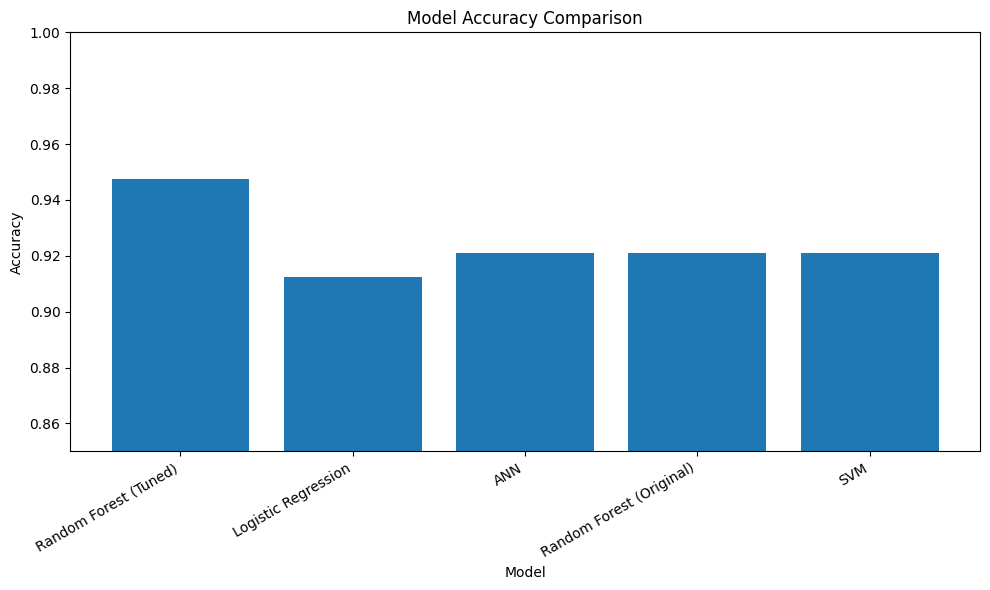

Accuracy comparison plot saved:
/content/ai_ml_project/data/model_accuracy_comparison.png


In [ ]:
# STEP 18B: Model comparison plot

plt.figure(figsize=(10, 6))

plt.bar(
    final_results["Model"],
    final_results["Accuracy"]
)

plt.ylabel("Accuracy")
plt.xlabel("Model")
plt.title("Model Accuracy Comparison")
plt.xticks(rotation=30, ha="right")
plt.ylim(0.85, 1.0)

plt.tight_layout()

accuracy_plot_path = (
    "/content/ai_ml_project/data/model_accuracy_comparison.png"
)

plt.savefig(
    accuracy_plot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Accuracy comparison plot saved:")
print(accuracy_plot_path)

In [ ]:
# STEP 19A: Verify final project structure

import os

project_root = "/content/ai_ml_project"

for root, dirs, files in os.walk(project_root):
    level = root.replace(project_root, "").count(os.sep)
    indent = "    " * level
    print(f"{indent}{os.path.basename(root)}/")

    for file in files:
        print(f"{indent}    {file}")

ai_ml_project/
    models/
        random_forest_tuned.pkl
    data/
        model_accuracy_comparison.png
        random_forest_permutation_importance.csv
        random_forest_final_evaluation.csv
        final_model_comparison.csv
        model_comparison.csv
        random_forest_impurity_importance.csv
        random_forest_error_analysis.csv


In [ ]:
# STEP 19B: Check final ML result files

required_files = [
    "data/random_forest_impurity_importance.csv",
    "data/random_forest_permutation_importance.csv",
    "data/random_forest_error_analysis.csv",
    "data/random_forest_final_evaluation.csv",
    "data/model_comparison.csv",
    "data/model_accuracy_comparison.png"
]

print("FINAL RESULT FILE CHECK")
print("=" * 60)

for file in required_files:

    path = os.path.join(project_root, file)

    if os.path.exists(path):
        size_kb = os.path.getsize(path) / 1024
        print(f"✅ {file} — {size_kb:.2f} KB")
    else:
        print(f"❌ MISSING: {file}")

FINAL RESULT FILE CHECK
✅ data/random_forest_impurity_importance.csv — 0.71 KB
✅ data/random_forest_permutation_importance.csv — 1.45 KB
✅ data/random_forest_error_analysis.csv — 1.90 KB
✅ data/random_forest_final_evaluation.csv — 0.23 KB
✅ data/model_comparison.csv — 0.33 KB
✅ data/model_accuracy_comparison.png — 163.69 KB


In [ ]:
# STEP 19C: Create final project summary

project_summary = {
    "Final_Model": "Random Forest (Tuned)",
    "Accuracy": 0.9474,
    "Precision": 0.9583,
    "Recall": 0.9583,
    "F1_Score": 0.9583,
    "ROC_AUC": 0.9940,
    "True_Negatives": 39,
    "False_Positives": 3,
    "False_Negatives": 3,
    "True_Positives": 69
}

summary_df = pd.DataFrame(
    [project_summary]
)

summary_path = os.path.join(
    project_root,
    "data/final_model_summary.csv"
)

summary_df.to_csv(
    summary_path,
    index=False
)

print("Final model summary saved successfully.")
display(summary_df)

Final model summary saved successfully.


,Final_Model,Accuracy,Precision,Recall,F1_Score,ROC_AUC,True_Negatives,False_Positives,False_Negatives,True_Positives
0,Random Forest (Tuned),0.9474,0.9583,0.9583,0.9583,0.994,39,3,3,69


In [ ]:
# STEP 20A: Final project structure

import os

project_root = "/content/ai_ml_project"

for root, dirs, files in os.walk(project_root):
    level = root.replace(project_root, "").count(os.sep)
    indent = "    " * level

    print(f"{indent}{os.path.basename(root)}/")

    for file in sorted(files):
        print(f"{indent}    {file}")

ai_ml_project/
    models/
        random_forest_tuned.pkl
    data/
        final_model_comparison.csv
        final_model_summary.csv
        model_accuracy_comparison.png
        model_comparison.csv
        random_forest_error_analysis.csv
        random_forest_final_evaluation.csv
        random_forest_impurity_importance.csv
        random_forest_permutation_importance.csv


In [ ]:
# STEP 20B: Check important project files

files_to_check = [
    "README.md",
    "requirements.txt",
    ".gitignore",
    "LICENSE",
    "notebooks/full_pipeline.ipynb",
    "models/random_forest.pkl",
]

print("GITHUB PROJECT CHECK")
print("=" * 60)

for relative_path in files_to_check:
    path = os.path.join(project_root, relative_path)

    if os.path.exists(path):
        print(f"✅ {relative_path}")
    else:
        print(f"⚠️ Missing: {relative_path}")

GITHUB PROJECT CHECK
⚠️ Missing: README.md
⚠️ Missing: requirements.txt
⚠️ Missing: .gitignore
⚠️ Missing: LICENSE
⚠️ Missing: notebooks/full_pipeline.ipynb
⚠️ Missing: models/random_forest.pkl


In [ ]:
import os

print("SEARCHING FOR EXISTING PROJECT FILES")
print("=" * 60)

search_names = [
    "README.md",
    "requirements.txt",
    ".gitignore",
    "LICENSE",
    "full_pipeline.ipynb",
    "random_forest.pkl"
]

search_root = "/content"

for name in search_names:
    print(f"\n🔎 {name}")
    found = False

    for root, dirs, files in os.walk(search_root):
        if name in files:
            path = os.path.join(root, name)
            print(f"   ✅ {path}")
            found = True

    if not found:
        print("   ❌ Not found anywhere in /content")

SEARCHING FOR EXISTING PROJECT FILES

🔎 README.md
   ✅ /content/sample_data/README.md

🔎 requirements.txt
   ❌ Not found anywhere in /content

🔎 .gitignore
   ❌ Not found anywhere in /content

🔎 LICENSE
   ❌ Not found anywhere in /content

🔎 full_pipeline.ipynb
   ❌ Not found anywhere in /content

🔎 random_forest.pkl
   ❌ Not found anywhere in /content


In [ ]:
import os
import joblib

project_root = "/content/ai_ml_project"
model_dir = os.path.join(project_root, "models")

os.makedirs(model_dir, exist_ok=True)

# Save the final tuned Random Forest
model_path = os.path.join(model_dir, "random_forest.pkl")

joblib.dump(rf_final, model_path)

print("✅ Final Random Forest saved successfully")
print(f"📁 {model_path}")
print(f"📦 File size: {os.path.getsize(model_path) / 1024:.2f} KB")

✅ Final Random Forest saved successfully
📁 /content/ai_ml_project/models/random_forest.pkl
📦 File size: 552.52 KB


In [ ]:
import os

if os.path.exists("/content/ai_ml_project/models/random_forest.pkl"):
    print("✅ random_forest.pkl is ready for GitHub")
else:
    print("❌ Model was not saved")

✅ random_forest.pkl is ready for GitHub


In [ ]:
requirements = """pandas
numpy
scikit-learn
matplotlib
seaborn
joblib
tensorflow
jupyter
openpyxl
"""

requirements_path = "/content/ai_ml_project/requirements.txt"

with open(requirements_path, "w") as f:
    f.write(requirements)

print("✅ requirements.txt created")
print(requirements_path)

print("\nContents:")
print(requirements)

✅ requirements.txt created
/content/ai_ml_project/requirements.txt

Contents:
pandas
numpy
scikit-learn
matplotlib
seaborn
joblib
tensorflow
jupyter
openpyxl



In [ ]:
import os

path = "/content/ai_ml_project/requirements.txt"

if os.path.exists(path):
    print(f"✅ requirements.txt exists — {os.path.getsize(path)} bytes")
else:
    print("❌ requirements.txt was not created")

✅ requirements.txt exists — 80 bytes


In [ ]:
gitignore = """# Python
__pycache__/
*.py[cod]
*.so

# Jupyter Notebook
.ipynb_checkpoints/

# Virtual environments
venv/
env/
.venv/

# Google Colab
*.log

# OS files
.DS_Store
Thumbs.db

# IDE files
.vscode/
.idea/

# Temporary files
*.tmp
*.temp

# Python packaging
build/
dist/
*.egg-info/

# Large temporary/generated files
/content/
"""

gitignore_path = "/content/ai_ml_project/.gitignore"

with open(gitignore_path, "w") as f:
    f.write(gitignore)

print("✅ .gitignore created")
print(gitignore_path)

✅ .gitignore created
/content/ai_ml_project/.gitignore


In [ ]:
import os

path = "/content/ai_ml_project/.gitignore"

if os.path.exists(path):
    print("✅ .gitignore is ready for GitHub")
    print("\nContents:")
    with open(path, "r") as f:
        print(f.read())
else:
    print("❌ .gitignore was not created")

✅ .gitignore is ready for GitHub

Contents:
# Python
__pycache__/
*.py[cod]
*.so

# Jupyter Notebook
.ipynb_checkpoints/

# Virtual environments
venv/
env/
.venv/

# Google Colab
*.log

# OS files
.DS_Store
Thumbs.db

# IDE files
.vscode/
.idea/

# Temporary files
*.tmp
*.temp

# Python packaging
build/
dist/
*.egg-info/

# Large temporary/generated files
/content/



In [ ]:
license_text = """MIT License

Copyright (c) 2026 Sadiya Tabassum

Permission is hereby granted, free of charge, to any person obtaining a copy
of this software and associated documentation files (the "Software"), to deal
in the Software without restriction, including without limitation the rights
to use, copy, modify, merge, publish, distribute, sublicense, and/or sell
copies of the Software, and to permit persons to whom the Software is
furnished to do so, subject to the following conditions:

The above copyright notice and this permission notice shall be included in
all copies or substantial portions of the Software.

THE SOFTWARE IS PROVIDED "AS IS", WITHOUT WARRANTY OF ANY KIND, EXPRESS OR
IMPLIED, INCLUDING BUT NOT LIMITED TO THE WARRANTIES OF MERCHANTABILITY,
FITNESS FOR A PARTICULAR PURPOSE AND NONINFRINGEMENT. IN NO EVENT SHALL THE
AUTHORS OR COPYRIGHT HOLDERS BE LIABLE FOR ANY CLAIM, DAMAGES OR OTHER
LIABILITY, WHETHER IN AN ACTION OF CONTRACT, TORT OR OTHERWISE, ARISING FROM,
OUT OF OR IN CONNECTION WITH THE SOFTWARE OR THE USE OR OTHER DEALINGS IN
THE SOFTWARE.
"""

license_path = "/content/ai_ml_project/LICENSE"

with open(license_path, "w") as f:
    f.write(license_text)

print("✅ LICENSE created")
print(license_path)

✅ LICENSE created
/content/ai_ml_project/LICENSE


In [ ]:
import os

path = "/content/ai_ml_project/LICENSE"

print("✅ LICENSE ready for GitHub" if os.path.exists(path)
      else "❌ LICENSE was not created")

✅ LICENSE ready for GitHub


In [ ]:
import os

project_root = "/content/ai_ml_project"
readme_path = os.path.join(project_root, "README.md")

lines = [
    "# Breast Cancer Classification Using Machine Learning",
    "",
    "## Project Overview",
    "",
    "This project develops an end-to-end machine learning pipeline for breast cancer classification using quantitative tumor features.",
    "",
    "The objective is to classify tumor samples as Benign or Malignant and compare multiple machine learning algorithms before selecting the best-performing model.",
    "",
    "The project includes model comparison, feature selection, hyperparameter tuning, cross-validation, model evaluation, feature importance, permutation importance, and error analysis.",
    "",
    "> Disclaimer: This is an educational and research-oriented machine learning project. It is not intended for clinical diagnosis or medical decision-making.",
    "",
    "## Objectives",
    "",
    "- Build an end-to-end machine learning classification pipeline",
    "- Compare multiple supervised learning algorithms",
    "- Perform feature selection",
    "- Optimize the Random Forest model",
    "- Use cross-validation for model selection",
    "- Evaluate classification performance using multiple metrics",
    "- Analyze important predictive features",
    "- Perform error analysis",
    "- Save the final trained model",
    "",
    "## Models Evaluated",
    "",
    "1. Logistic Regression",
    "2. Support Vector Machine (SVM)",
    "3. Random Forest",
    "4. Tuned Random Forest",
    "5. Artificial Neural Network (ANN)",
    "",
    "## Final Model",
    "",
    "The Tuned Random Forest was selected as the final model because it achieved the strongest overall performance.",
    "",
    "### Final Performance",
    "",
    "| Metric | Score |",
    "|---|---:|",
    "| Accuracy | 94.74% |",
    "| Precision | 95.83% |",
    "| Recall | 95.83% |",
    "| F1 Score | 95.83% |",
    "| ROC-AUC | 99.40% |",
    "",
    "### Confusion Matrix",
    "",
    "| Actual / Predicted | Benign | Malignant |",
    "|---|---:|---:|",
    "| Benign | 39 | 3 |",
    "| Malignant | 3 | 69 |",
    "",
    "- True Negatives: 39",
    "- False Positives: 3",
    "- False Negatives: 3",
    "- True Positives: 69",
    "",
    "The model correctly classified 108 out of 114 test samples.",
    "",
    "## Why Recall Matters",
    "",
    "In a cancer classification problem, recall is particularly important because a false negative represents a malignant sample incorrectly classified as benign.",
    "",
    "The final model achieved 95.83% recall with 3 false-negative predictions on the test set.",
    "",
    "## Model Comparison",
    "",
    "| Model | Accuracy | Precision | Recall | F1 Score | ROC-AUC |",
    "|---|---:|---:|---:|---:|---:|",
    "| Tuned Random Forest | 94.74% | 95.83% | 95.83% | 95.83% | 99.40% |",
    "| Logistic Regression | 91.23% | 95.59% | 90.28% | 92.86% | 98.61% |",
    "| ANN | 92.11% | 95.65% | 91.67% | 93.62% | 98.48% |",
    "| Random Forest (Original) | 92.11% | 95.65% | 91.67% | 93.62% | 98.41% |",
    "| SVM | 92.11% | 95.65% | 91.67% | 93.62% | 98.41% |",
    "",
    "## Feature Selection",
    "",
    "Feature selection was performed using SelectKBest with the ANOVA F-test (f_classif).",
    "",
    "Feature importance was investigated using impurity-based Random Forest importance and permutation importance.",
    "",
    "Important features identified during the analysis included:",
    "",
    "- Worst concave points",
    "- Mean concave points",
    "- Worst area",
    "",
    "## Error Analysis",
    "",
    "The final model produced 3 false negatives and 3 false positives.",
    "",
    "Misclassified observations were examined using their predicted malignant probabilities. Error analysis was used to understand model behavior beyond aggregate performance metrics.",
    "",
    "## Technologies Used",
    "",
    "- Python",
    "- R",
    "- NumPy",
    "- Pandas",
    "- Scikit-learn",
    "- Matplotlib",
    "- Seaborn",
    "- Joblib",
    "- TensorFlow / Keras",
    "",
    "## Machine Learning Techniques",
    "",
    "- Logistic Regression",
    "- Support Vector Machine",
    "- Random Forest",
    "- GridSearchCV",
    "- Stratified Cross-Validation",
    "- SelectKBest",
    "- ANOVA F-test",
    "- Artificial Neural Network",
    "- Confusion Matrix",
    "- ROC-AUC",
    "- Feature Importance",
    "- Permutation Importance",
    "- Error Analysis",
    "",
    "## Project Structure",
    "",
    "ai_ml_project/",
    "├── README.md",
    "├── requirements.txt",
    "├── .gitignore",
    "├── LICENSE",
    "├── data/",
    "├── models/",
    "├── notebooks/",
    "├── src/",
    "└── R/",
    "",
    "## Reproducibility",
    "",
    "Install the required dependencies:",
    "",
    "pip install -r requirements.txt",
    "",
    "The final trained Random Forest model is stored in:",
    "",
    "models/random_forest.pkl",
    "",
    "## Key Learning Outcomes",
    "",
    "- End-to-end machine learning workflow",
    "- Biomedical classification",
    "- Model comparison",
    "- Feature selection",
    "- Hyperparameter optimization",
    "- Cross-validation",
    "- Model evaluation",
    "- Model interpretability",
    "- Error analysis",
    "- Model serialization",
    "- Reproducible project organization",
    "",
    "## Future Improvements",
    "",
    "- External validation using an independent dataset",
    "- SHAP-based explainability",
    "- Probability calibration",
    "- Threshold optimization",
    "- Additional hyperparameter optimization",
    "- Model deployment through an API or web application",
    "",
    "## Author",
    "",
    "Sadiya Tabassum",
    "",
    "Biotechnology | Bioinformatics | AI/ML | Scientific & Clinical Data Analytics"
]

with open(readme_path, "w", encoding="utf-8") as f:
    f.write("\n".join(lines))

print("✅ README.md created successfully")
print("📁", readme_path)
print("📦 Size:", round(os.path.getsize(readme_path) / 1024, 2), "KB")

✅ README.md created successfully
📁 /content/ai_ml_project/README.md
📦 Size: 4.46 KB


In [ ]:
import os

project_root = "/content/ai_ml_project"

print("GITHUB FILE CHECK")
print("=" * 50)

for file in ["README.md", "requirements.txt", ".gitignore", "LICENSE"]:
    path = os.path.join(project_root, file)
    if os.path.exists(path):
        print("✅", file)
    else:
        print("❌", file)

GITHUB FILE CHECK
✅ README.md
✅ requirements.txt
✅ .gitignore
✅ LICENSE


In [ ]:
# ============================================================
# AI/ML FOR BIOMEDICAL R&D
# Step 1 — Dataset Definition & Quality Assessment
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer

# Reproducibility
RANDOM_STATE = 42

# Load dataset
data = load_breast_cancer(as_frame=True)

df = data.frame.copy()
df.rename(columns={"target": "diagnosis"}, inplace=True)

print("Dataset shape:", df.shape)

print("\nTarget classes:")
print(df["diagnosis"].value_counts())

print("\nMissing values:")
print(df.isnull().sum().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

print("\nFeature count:")
print(df.drop(columns=["diagnosis"]).shape[1])

display(df.head())

Dataset shape: (569, 31)

Target classes:
diagnosis
1    357
0    212
Name: count, dtype: int64

Missing values:
0

Duplicate rows:
0

Feature count:
30


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [ ]:
# Create an interpretable diagnosis label

df["diagnosis_label"] = df["diagnosis"].map({
    0: "Malignant",
    1: "Benign"
})

print(df["diagnosis_label"].value_counts())

diagnosis_label
Benign       357
Malignant    212
Name: count, dtype: int64


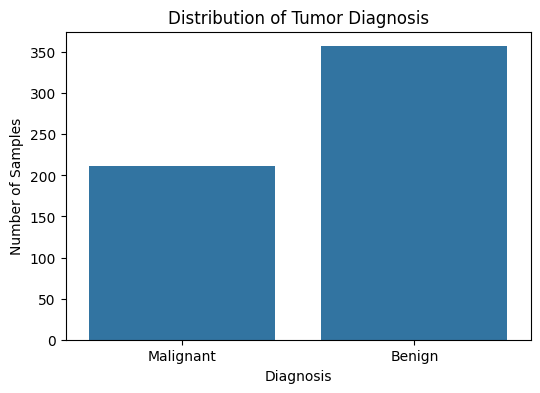

In [ ]:
plt.figure(figsize=(6, 4))

sns.countplot(
    data=df,
    x="diagnosis_label"
)

plt.title("Distribution of Tumor Diagnosis")
plt.xlabel("Diagnosis")
plt.ylabel("Number of Samples")
plt.show()

# AI/ML-Driven Biomarker Discovery for Breast Cancer

## Exploratory Biomedical R&D Workflow

This project applies machine learning to quantitative breast tumor characteristics to distinguish benign and malignant tumor samples.

The primary objective is not only tumor classification, but also identification and prioritization of informative quantitative features that may serve as candidate biomarkers for further biomedical investigation.

> **Important:** This is an exploratory computational R&D project. The identified features are candidate predictive features and are not clinically validated biomarkers.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer

RANDOM_STATE = 42

# Load Breast Cancer Wisconsin Diagnostic dataset
data = load_breast_cancer(as_frame=True)

# Convert to DataFrame
df = data.frame.copy()

# Rename target column
df.rename(columns={"target": "diagnosis"}, inplace=True)

print("Dataset shape:", df.shape)
print("Number of samples:", df.shape[0])
print("Number of features:", df.shape[1] - 1)

Dataset shape: (569, 31)
Number of samples: 569
Number of features: 30


In [ ]:
print("\nTarget distribution:")
print(df["diagnosis"].value_counts())

print("\nTarget proportions:")
print(df["diagnosis"].value_counts(normalize=True))


Target distribution:
diagnosis
1    357
0    212
Name: count, dtype: int64

Target proportions:
diagnosis
1    0.627417
0    0.372583
Name: proportion, dtype: float64


In [ ]:
df["diagnosis_label"] = df["diagnosis"].map({
    0: "Malignant",
    1: "Benign"
})

print("\nDiagnosis distribution:")
print(df["diagnosis_label"].value_counts())


Diagnosis distribution:
diagnosis_label
Benign       357
Malignant    212
Name: count, dtype: int64


In [ ]:
print("Missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

print("\nData types:")
print(df.dtypes.value_counts())

print("\nDataset information:")
df.info()

Missing values: 0
Duplicate rows: 0

Data types:
float64    30
int64       1
object      1
Name: count, dtype: int64

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64


In [ ]:
display(df.head())

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,diagnosis,diagnosis_label
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0,Malignant
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0,Malignant
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0,Malignant
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0,Malignant
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0,Malignant


In [ ]:
display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
mean texture,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
mean area,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
mean compactness,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
mean concavity,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
mean concave points,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
mean symmetry,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744


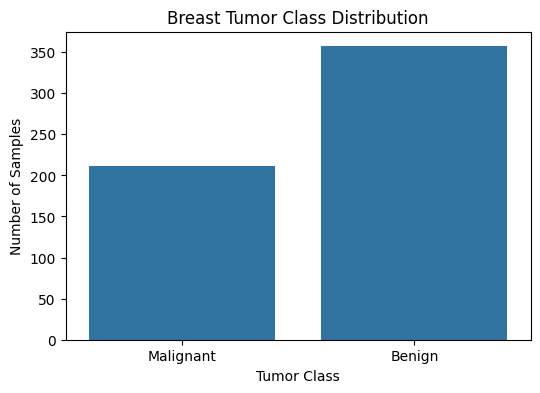

In [ ]:
plt.figure(figsize=(6, 4))

sns.countplot(
    data=df,
    x="diagnosis_label"
)

plt.title("Breast Tumor Class Distribution")
plt.xlabel("Tumor Class")
plt.ylabel("Number of Samples")

plt.show()

## 3. Exploratory Data Analysis

Exploratory data analysis is performed to understand the distribution, variability, relationships, and class-separation patterns of the quantitative tumor features.

The analysis will help determine whether the dataset contains measurable patterns that may support machine-learning-based tumor classification and feature prioritization.

In [ ]:
# Separate predictors and target

feature_columns = data.feature_names

X = df[feature_columns].copy()
y = df["diagnosis"].copy()

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

print("\nTarget encoding:")
print("0 = Malignant")
print("1 = Benign")

Feature matrix shape: (569, 30)
Target shape: (569,)

Target encoding:
0 = Malignant
1 = Benign


In [ ]:
# Summary statistics for all quantitative features

display(X.describe().T)

,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
mean texture,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
mean area,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
mean compactness,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
mean concavity,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
mean concave points,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
mean symmetry,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744


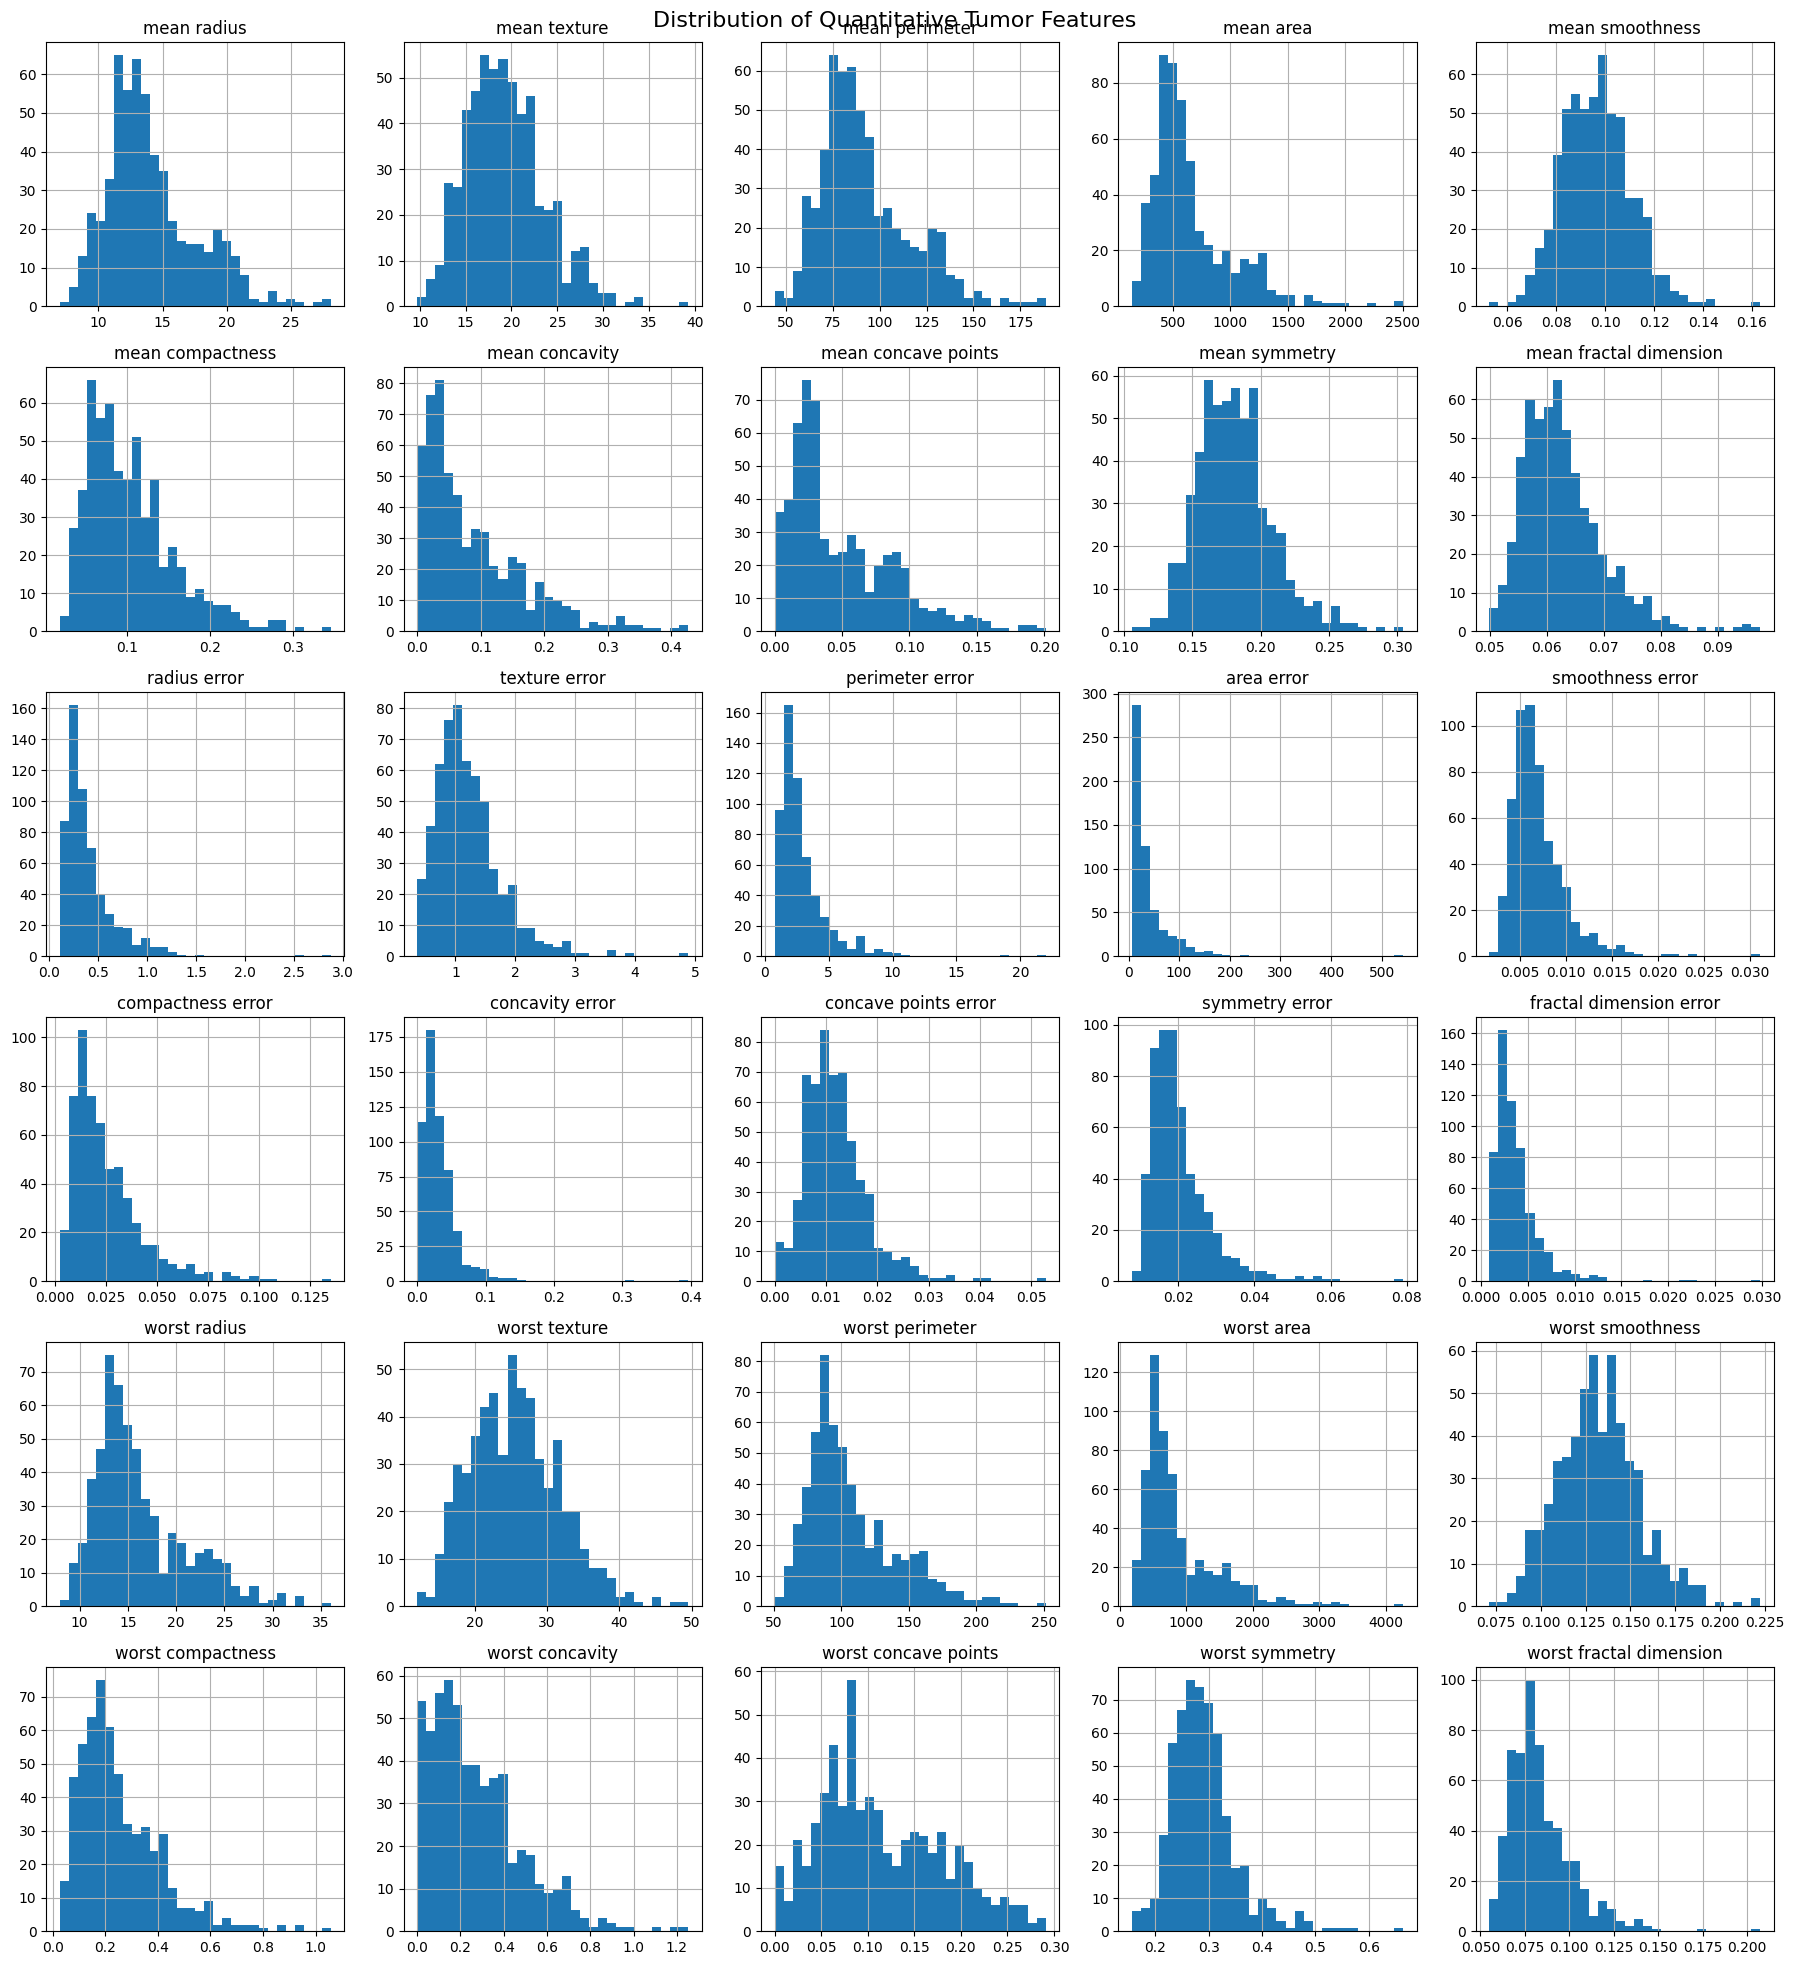

In [ ]:
# Plot distributions of all features

X.hist(
    figsize=(18, 20),
    bins=30
)

plt.suptitle(
    "Distribution of Quantitative Tumor Features",
    fontsize=16
)

plt.tight_layout()
plt.show()

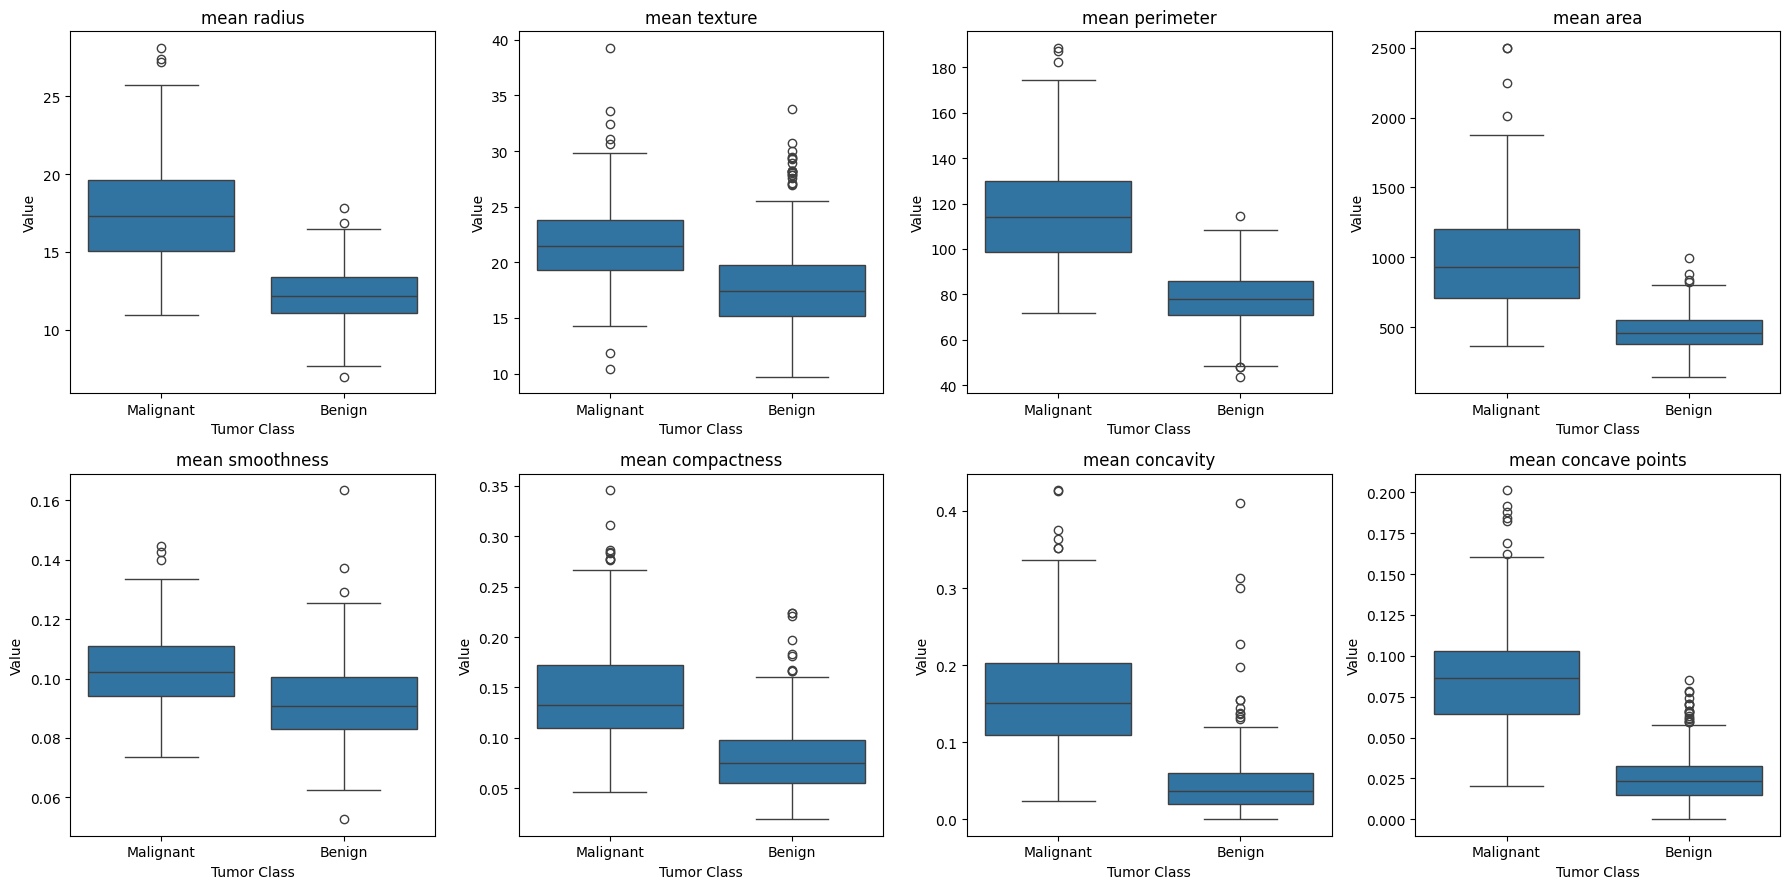

In [ ]:
selected_eda_features = [
    "mean radius",
    "mean texture",
    "mean perimeter",
    "mean area",
    "mean smoothness",
    "mean compactness",
    "mean concavity",
    "mean concave points"
]

fig, axes = plt.subplots(2, 4, figsize=(18, 9))

for ax, feature in zip(axes.flatten(), selected_eda_features):
    sns.boxplot(
        data=df,
        x="diagnosis_label",
        y=feature,
        ax=ax
    )

    ax.set_title(feature)
    ax.set_xlabel("Tumor Class")
    ax.set_ylabel("Value")

plt.tight_layout()
plt.show()

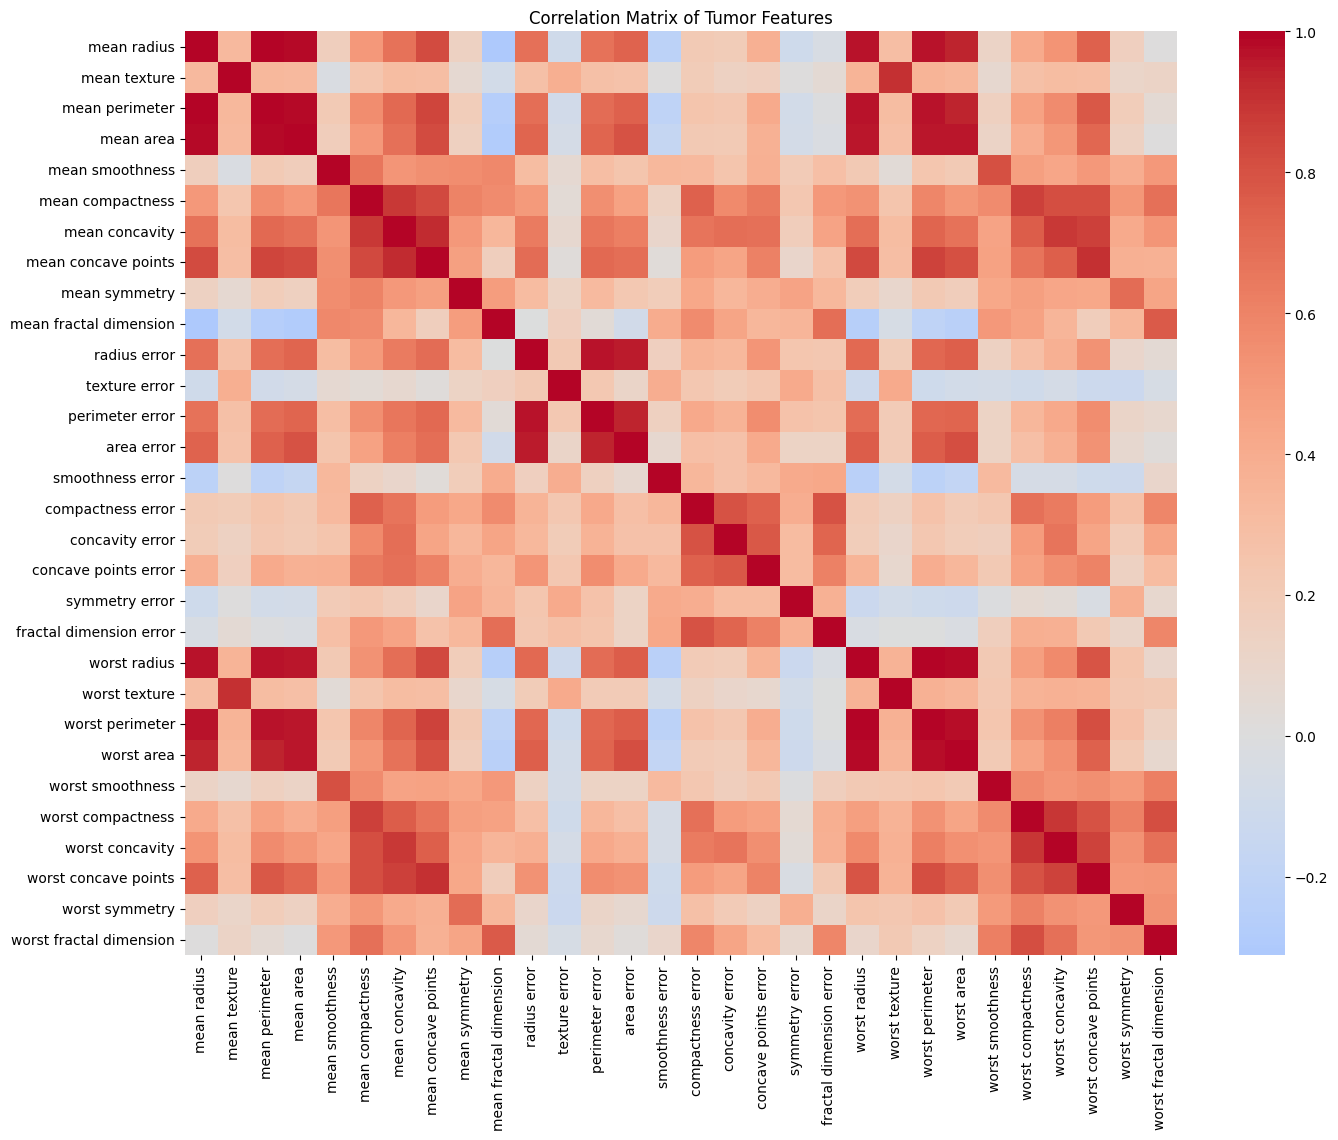

In [ ]:
plt.figure(figsize=(16, 12))

correlation_matrix = X.corr()

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0,
    square=False
)

plt.title("Correlation Matrix of Tumor Features")
plt.show()

In [ ]:
# Identify highly correlated feature pairs

corr_pairs = (
    correlation_matrix
    .where(np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool))
    .stack()
    .sort_values(ascending=False)
)

print("Top highly correlated feature pairs:")
display(corr_pairs.head(15))

Top highly correlated feature pairs:


,,0
mean radius,mean perimeter,0.997855
worst radius,worst perimeter,0.993708
mean radius,mean area,0.987357
mean perimeter,mean area,0.986507
worst radius,worst area,0.984015
worst perimeter,worst area,0.977578
radius error,perimeter error,0.972794
mean perimeter,worst perimeter,0.970387
mean radius,worst radius,0.969539
mean perimeter,worst radius,0.969476


## EDA – R&D Interpretation

The exploratory analysis demonstrates that the tumor dataset contains substantial variation across quantitative morphological features.

Several features show differences between benign and malignant tumor groups, suggesting that tumor morphology contains predictive information relevant to classification.

The correlation analysis also indicates that many tumor measurements are strongly related to one another. This suggests the presence of redundant information and motivates the use of feature-selection and dimensionality-reduction approaches during downstream analysis.

At this stage, these observations represent exploratory associations. They should not be interpreted as evidence that any individual feature is a clinically validated biomarker.

## 4. Train/Test Split

The dataset is divided into training and testing subsets before supervised preprocessing and feature selection.

The training set is used for model development, preprocessing, feature selection, and hyperparameter optimization.

The test set is held out and used only for final evaluation of the selected model.

In [ ]:
from sklearn.model_selection import train_test_split

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

print("\nTraining class distribution:")
print(y_train.value_counts())

print("\nTesting class distribution:")
print(y_test.value_counts())

Training samples: 455
Testing samples: 114

Training class distribution:
diagnosis
1    285
0    170
Name: count, dtype: int64

Testing class distribution:
diagnosis
1    72
0    42
Name: count, dtype: int64


In [ ]:
stratify=y

In [ ]:
print("Original dataset:")
print(y.value_counts(normalize=True))

print("\nTraining set:")
print(y_train.value_counts(normalize=True))

print("\nTesting set:")
print(y_test.value_counts(normalize=True))

Original dataset:
diagnosis
1    0.627417
0    0.372583
Name: proportion, dtype: float64

Training set:
diagnosis
1    0.626374
0    0.373626
Name: proportion, dtype: float64

Testing set:
diagnosis
1    0.631579
0    0.368421
Name: proportion, dtype: float64


## 4.1 Feature Scaling

Feature scaling is applied to the training data so that quantitative variables with different numerical ranges can be placed on a comparable scale.

The scaler is fitted using the training data only and then applied to both training and testing data.

This prevents information from the test set from influencing the preprocessing step.

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit ONLY on training data
X_train_scaled = scaler.fit_transform(X_train)

# Apply the same transformation to test data
X_test_scaled = scaler.transform(X_test)

print("Scaled training shape:", X_train_scaled.shape)
print("Scaled testing shape:", X_test_scaled.shape)

Scaled training shape: (455, 30)
Scaled testing shape: (114, 30)


In [ ]:
scaler.fit_transform(X_train)
scaler.transform(X_test)

array([[ 1.56851278,  2.16401585,  1.74286587, ...,  1.20214432,
        -0.14043064,  0.90036171],
       [-0.84027641, -0.5970672 , -0.8741735 , ..., -1.10124064,
        -0.81429139, -0.71323608],
       [-0.07072262,  1.19138742,  0.03202768, ...,  0.57255843,
         1.14997397,  1.86841162],
       ...,
       [ 0.3583966 , -0.44935493,  0.48264098, ...,  1.63386036,
         0.54117564,  1.91191948],
       [-0.41401799,  1.07321761, -0.42314565, ...,  0.06139464,
        -0.1280378 ,  0.64747227],
       [-0.6829327 , -0.69932953, -0.66607058, ..., -0.23615965,
        -0.16211811, -0.20147486]])

In [ ]:
print("Training feature means:")
print(np.mean(X_train_scaled, axis=0)[:5])

print("\nTraining feature standard deviations:")
print(np.std(X_train_scaled, axis=0)[:5])

Training feature means:
[-2.92806072e-16  6.24652955e-16 -1.62995380e-16 -1.71779562e-16
  6.24652955e-17]

Training feature standard deviations:
[1. 1. 1. 1. 1.]


## Leakage Prevention Strategy

To maintain a realistic estimate of model generalization:

- The test set is isolated before supervised preprocessing.
- The scaler is fitted only on the training set.
- Feature selection will be performed using training data only.
- Hyperparameter tuning will use cross-validation within the training set.
- The test set will be used only once for final model evaluation.

## 5. Feature Selection

Feature selection is performed to identify quantitative tumor characteristics that provide strong discriminatory information between benign and malignant samples.

The ANOVA F-test is applied using the training data only. This prevents the held-out test set from influencing feature selection.

Features with stronger F-statistics and lower p-values provide stronger evidence of class-associated variation within the training dataset.

In [ ]:
from sklearn.feature_selection import SelectKBest, f_classif

In [ ]:
# ============================================================
# PROJECT SETUP + DATASET LOADING
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.preprocessing import StandardScaler

# Reproducibility
RANDOM_STATE = 42

# Load dataset
data = load_breast_cancer(as_frame=True)

# Convert to DataFrame
df = data.frame.copy()

# Rename target column
df.rename(columns={"target": "diagnosis"}, inplace=True)

# Create readable diagnosis labels
df["diagnosis_label"] = df["diagnosis"].map({
    0: "Malignant",
    1: "Benign"
})

# Define features and target
X = df[data.feature_names].copy()
y = df["diagnosis"].copy()

print("Dataset shape:", df.shape)
print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

print("\nDiagnosis distribution:")
print(df["diagnosis_label"].value_counts())

print("\nMissing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

Dataset shape: (569, 32)
Feature matrix shape: (569, 30)
Target shape: (569,)

Diagnosis distribution:
diagnosis_label
Benign       357
Malignant    212
Name: count, dtype: int64

Missing values: 0
Duplicate rows: 0


In [ ]:
# ============================================================
# TRAIN / TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

print("\nTraining class distribution:")
print(y_train.value_counts())

print("\nTesting class distribution:")
print(y_test.value_counts())

Training samples: 455
Testing samples: 114

Training class distribution:
diagnosis
1    285
0    170
Name: count, dtype: int64

Testing class distribution:
diagnosis
1    72
0    42
Name: count, dtype: int64


In [ ]:
# ============================================================
# ANOVA FEATURE SELECTION
# ============================================================

f_scores, p_values = f_classif(X_train, y_train)

anova_results = pd.DataFrame({
    "Feature": X_train.columns,
    "F_Score": f_scores,
    "P_Value": p_values
})

anova_results = anova_results.sort_values(
    by="F_Score",
    ascending=False
).reset_index(drop=True)

display(anova_results)

,Feature,F_Score,P_Value
0,worst concave points,795.223341,9.269318e-102
1,worst perimeter,719.598823,1.327313e-95
2,mean concave points,703.364031,3.135578e-94
3,worst radius,687.430367,7.296427e-93
4,mean perimeter,565.485755,1.011815e-81
5,worst area,541.713694,2.150031e-79
6,mean radius,523.613907,1.387363e-77
7,mean area,469.516453,5.741182e-72
8,mean concavity,416.374874,4.058059e-66
9,worst concavity,365.747389,3.351548e-60


In [ ]:
# ============================================================
# STEP 6A — STANDARDIZATION FOR PCA
# ============================================================

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit scaler ONLY on training data
X_train_scaled = scaler.fit_transform(X_train)

# Apply the same transformation to test data
X_test_scaled = scaler.transform(X_test)

print("Scaled training shape:", X_train_scaled.shape)
print("Scaled testing shape:", X_test_scaled.shape)

Scaled training shape: (455, 30)
Scaled testing shape: (114, 30)


In [ ]:
# ============================================================
# STEP 6B — PCA
# ============================================================

from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=RANDOM_STATE)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print("Training PCA shape:", X_train_pca.shape)
print("Testing PCA shape:", X_test_pca.shape)

print("\nExplained variance ratio:")
print(pca.explained_variance_ratio_)

print("\nTotal variance explained by 2 PCs:",
      pca.explained_variance_ratio_.sum())

Training PCA shape: (455, 2)
Testing PCA shape: (114, 2)

Explained variance ratio:
[0.44413492 0.18944618]

Total variance explained by 2 PCs: 0.6335811006772495


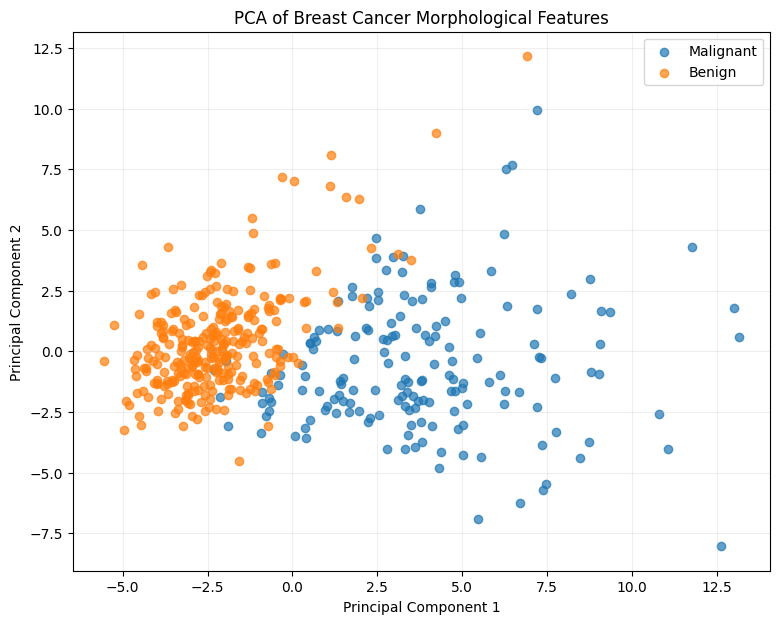

In [ ]:
# ============================================================
# STEP 6C — PCA EXPLORATORY VISUALIZATION
# ============================================================

plt.figure(figsize=(9, 7))

for diagnosis in sorted(y_train.unique()):
    mask = y_train.values == diagnosis

    label = "Malignant" if diagnosis == 0 else "Benign"

    plt.scatter(
        X_train_pca[mask, 0],
        X_train_pca[mask, 1],
        label=label,
        alpha=0.7
    )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA of Breast Cancer Morphological Features")
plt.legend()
plt.grid(alpha=0.2)

plt.show()

In [ ]:
# ============================================================
# STEP 7A — MACHINE LEARNING MODEL DEVELOPMENT
# ============================================================

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

# ------------------------------------------------------------
# Models
# ------------------------------------------------------------

logistic_model = LogisticRegression(
    max_iter=5000,
    random_state=RANDOM_STATE
)

svm_model = SVC(
    probability=True,
    random_state=RANDOM_STATE
)

rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

ann_model = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation="relu",
    solver="adam",
    max_iter=1000,
    random_state=RANDOM_STATE
)

print("Models initialized successfully.")

Models initialized successfully.


In [ ]:
# ============================================================
# STEP 7B — MODEL TRAINING
# ============================================================

models = {
    "Logistic Regression": logistic_model,
    "SVM": svm_model,
    "Random Forest": rf_model,
    "ANN": ann_model
}

for name, model in models.items():

    model.fit(X_train_scaled, y_train)

    print(f"{name} trained successfully.")

Logistic Regression trained successfully.
SVM trained successfully.
Random Forest trained successfully.
ANN trained successfully.


In [ ]:
# ============================================================
# STEP 7C — BASELINE MODEL EVALUATION
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

results = []

for name, model in models.items():

    # Predictions
    y_pred = model.predict(X_test_scaled)

    # Probability / decision score for ROC-AUC
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test_scaled)[:, 1]
    else:
        y_score = model.decision_function(X_test_scaled)

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_score)

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC-AUC": roc_auc
    })

# Create comparison table
baseline_results = pd.DataFrame(results)

baseline_results = baseline_results.sort_values(
    by="ROC-AUC",
    ascending=False
).reset_index(drop=True)

display(baseline_results.round(4))

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.9825,0.9861,0.9861,0.9861,0.9954
1,SVM,0.9825,0.9861,0.9861,0.9861,0.9950
2,Random Forest,0.9474,0.9583,0.9583,0.9583,0.9937
3,ANN,0.9649,0.9857,0.9583,0.9718,0.9937


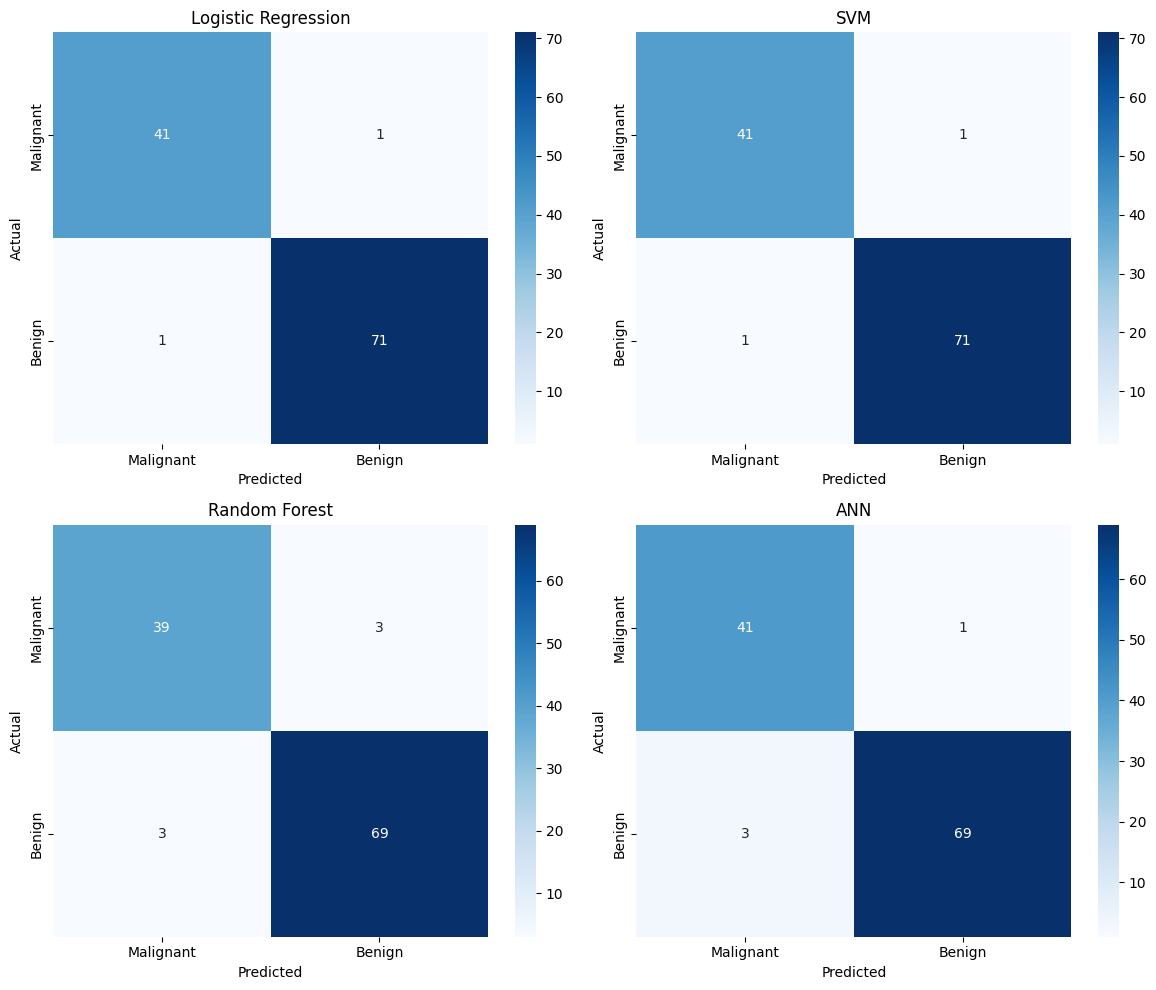

In [ ]:
# ============================================================
# STEP 7D — CONFUSION MATRICES
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

for ax, (name, model) in zip(axes, models.items()):

    y_pred = model.predict(X_test_scaled)

    cm = confusion_matrix(y_test, y_pred)

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        ax=ax,
        xticklabels=["Malignant", "Benign"],
        yticklabels=["Malignant", "Benign"]
    )

    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

In [ ]:
display(baseline_results.round(4))

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.9825,0.9861,0.9861,0.9861,0.9954
1,SVM,0.9825,0.9861,0.9861,0.9861,0.9950
2,Random Forest,0.9474,0.9583,0.9583,0.9583,0.9937
3,ANN,0.9649,0.9857,0.9583,0.9718,0.9937


In [ ]:
X_train
X_test
y_train
y_test

,diagnosis
256,0
428,1
501,0
363,1
564,0
...,...
95,0
128,1
257,0
228,1


In [ ]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (455, 30)
X_test: (114, 30)
y_train: (455,)
y_test: (114,)


In [ ]:
print(type(X_train))
print(type(X_test))
print(type(y_train))
print(type(y_test))

<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.series.Series'>
<class 'pandas.core.series.Series'>


In [ ]:
print("y_train distribution:")
print(y_train.value_counts())

print("\ny_test distribution:")
print(y_test.value_counts())

y_train distribution:
diagnosis
1    285
0    170
Name: count, dtype: int64

y_test distribution:
diagnosis
1    72
0    42
Name: count, dtype: int64


In [ ]:
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

In [ ]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

print(cv)

StratifiedKFold(n_splits=5, random_state=42, shuffle=True)


In [ ]:
# Step 8B — Logistic Regression Hyperparameter Tuning

log_reg = LogisticRegression(
    max_iter=5000,
    random_state=42
)

log_reg_params = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear', 'lbfgs'],
    'class_weight': [None, 'balanced']
}

log_reg_grid = GridSearchCV(
    estimator=log_reg,
    param_grid=log_reg_params,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1,
    return_train_score=True
)

log_reg_grid.fit(X_train, y_train.values.ravel())

print("Best Logistic Regression Parameters:")
print(log_reg_grid.best_params_)

print("\nBest Cross-Validation ROC-AUC:")
print(log_reg_grid.best_score_)

Best Logistic Regression Parameters:
{'C': 10, 'class_weight': 'balanced', 'solver': 'lbfgs'}

Best Cross-Validation ROC-AUC:
0.991124871001032


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
scoring='roc_auc'

In [ ]:
y_train.values.ravel()

array([1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1,
       1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1,
       0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1,
       0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0,
       1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1,
       1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1,
       0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0,
       0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0,
       0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1,
       1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1,
       1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1,
       0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0,
       1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1,

In [ ]:
# Step 8B — Logistic Regression Hyperparameter Tuning

from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.linear_model import LogisticRegression

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

log_reg = LogisticRegression(
    max_iter=5000,
    random_state=42
)

log_reg_params = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear', 'lbfgs'],
    'class_weight': [None, 'balanced']
}

log_reg_grid = GridSearchCV(
    estimator=log_reg,
    param_grid=log_reg_params,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1,
    return_train_score=True
)

log_reg_grid.fit(X_train, y_train.values.ravel())

print("Best Logistic Regression Parameters:")
print(log_reg_grid.best_params_)

print("\nBest Cross-Validation ROC-AUC:")
print(log_reg_grid.best_score_)

Best Logistic Regression Parameters:
{'C': 10, 'class_weight': 'balanced', 'solver': 'lbfgs'}

Best Cross-Validation ROC-AUC:
0.991124871001032


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [3]:
print("Variables available:")
print([x for x in dir() if not x.startswith("_")])

Variables available:
['GridSearchCV', 'In', 'Out', 'SVC', 'exit', 'get_ipython', 'quit', 'svm', 'svm_grid', 'svm_params']


In [6]:
# ============================================
# RECOVER TRAIN / TEST DATA
# ============================================

import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load Breast Cancer Wisconsin Diagnostic dataset
data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="diagnosis")

print("Dataset shape:", X.shape)
print("Target shape:", y.shape)

# Same stratified 80/20 split used in the project
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print("\nTrain/Test dimensions:")
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

Dataset shape: (569, 30)
Target shape: (569,)

Train/Test dimensions:
X_train: (455, 30)
X_test : (114, 30)
y_train: (455,)
y_test : (114,)


In [7]:
# ============================================
# STEP 8C — SVM HYPERPARAMETER TUNING
# ============================================

from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, StratifiedKFold

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

svm = SVC(
    probability=False,
    random_state=42
)

svm_params = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf']
}

svm_grid = GridSearchCV(
    estimator=svm,
    param_grid=svm_params,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1
)

svm_grid.fit(X_train, y_train)

print("Best SVM Parameters:")
print(svm_grid.best_params_)

print("\nBest Cross-Validation ROC-AUC:")
print(round(svm_grid.best_score_, 4))

Best SVM Parameters:
{'C': 10, 'kernel': 'linear'}

Best Cross-Validation ROC-AUC:
0.9894


In [8]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, StratifiedKFold

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

logreg_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(
        max_iter=5000,
        random_state=42
    ))
])

logreg_params = {
    'logreg__C': [0.01, 0.1, 1, 10, 100],
    'logreg__solver': ['liblinear', 'lbfgs']
}

logreg_grid = GridSearchCV(
    estimator=logreg_pipe,
    param_grid=logreg_params,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1
)

logreg_grid.fit(X_train, y_train)

print("Best Logistic Regression Parameters:")
print(logreg_grid.best_params_)

print("\nBest Cross-Validation ROC-AUC:")
print(round(logreg_grid.best_score_, 4))

Best Logistic Regression Parameters:
{'logreg__C': 1, 'logreg__solver': 'liblinear'}

Best Cross-Validation ROC-AUC:
0.996


In [9]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

rf_grid = GridSearchCV(
    estimator=rf,
    param_grid=rf_params,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

print("Best Random Forest Parameters:")
print(rf_grid.best_params_)

print("\nBest Cross-Validation ROC-AUC:")
print(round(rf_grid.best_score_, 4))

Best Random Forest Parameters:
{'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}

Best Cross-Validation ROC-AUC:
0.9896


In [10]:
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, StratifiedKFold

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

ann_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('ann', MLPClassifier(
        max_iter=1000,
        early_stopping=True,
        random_state=42
    ))
])

ann_params = {
    'ann__hidden_layer_sizes': [(32,), (64,), (32, 16)],
    'ann__alpha': [0.0001, 0.001]
}

ann_grid = GridSearchCV(
    estimator=ann_pipe,
    param_grid=ann_params,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1
)

ann_grid.fit(X_train, y_train)

print("Best ANN Parameters:")
print(ann_grid.best_params_)

print("\nBest Cross-Validation ROC-AUC:")
print(round(ann_grid.best_score_, 4))

Best ANN Parameters:
{'ann__alpha': 0.0001, 'ann__hidden_layer_sizes': (32, 16)}

Best Cross-Validation ROC-AUC:
0.9897


In [11]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# Best Logistic Regression model
final_model = logreg_grid.best_estimator_

# Fit only on training data
final_model.fit(X_train, y_train)

# Predictions on untouched test set
y_pred = final_model.predict(X_test)
y_prob = final_model.predict_proba(X_test)[:, 1]

# Evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("FINAL LOGISTIC REGRESSION MODEL")
print("--------------------------------")
print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1 Score :", round(f1, 4))
print("ROC-AUC  :", round(roc_auc, 4))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

FINAL LOGISTIC REGRESSION MODEL
--------------------------------
Accuracy : 0.9825
Precision: 0.9861
Recall   : 0.9861
F1 Score : 0.9861
ROC-AUC  : 0.9957

Confusion Matrix:
[[41  1]
 [ 1 71]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



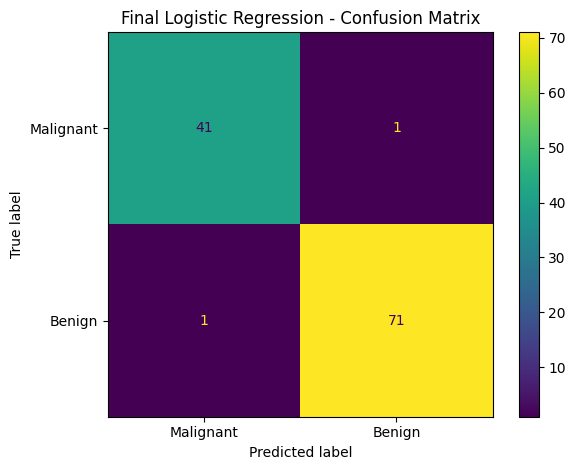

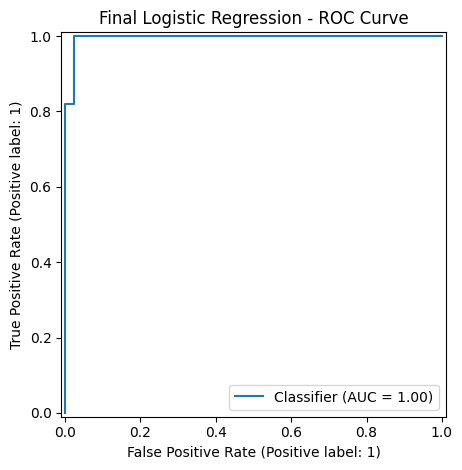

In [12]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay

# Confusion Matrix
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["Malignant", "Benign"]
)

plt.title("Final Logistic Regression - Confusion Matrix")
plt.tight_layout()
plt.show()


# ROC Curve
RocCurveDisplay.from_predictions(
    y_test,
    y_prob
)

plt.title("Final Logistic Regression - ROC Curve")
plt.tight_layout()
plt.show()

In [13]:
import pandas as pd
import numpy as np

# Get the trained Logistic Regression coefficients
logreg_model = final_model.named_steps['logreg']

feature_names = X_train.columns
coefficients = logreg_model.coef_[0]

feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients,
    'Absolute_Importance': np.abs(coefficients)
})

feature_importance = feature_importance.sort_values(
    'Absolute_Importance',
    ascending=False
).reset_index(drop=True)

print("Top 15 Features:")
display(feature_importance.head(15))

Top 15 Features:


,Feature,Coefficient,Absolute_Importance
0,worst texture,-1.242272,1.242272
1,radius error,-1.087929,1.087929
2,worst area,-0.979282,0.979282
3,area error,-0.958096,0.958096
4,worst radius,-0.946000,0.946000
5,worst concave points,-0.945296,0.945296
6,worst symmetry,-0.928729,0.928729
7,worst concavity,-0.827180,0.827180
8,worst perimeter,-0.764807,0.764807
9,worst smoothness,-0.759567,0.759567


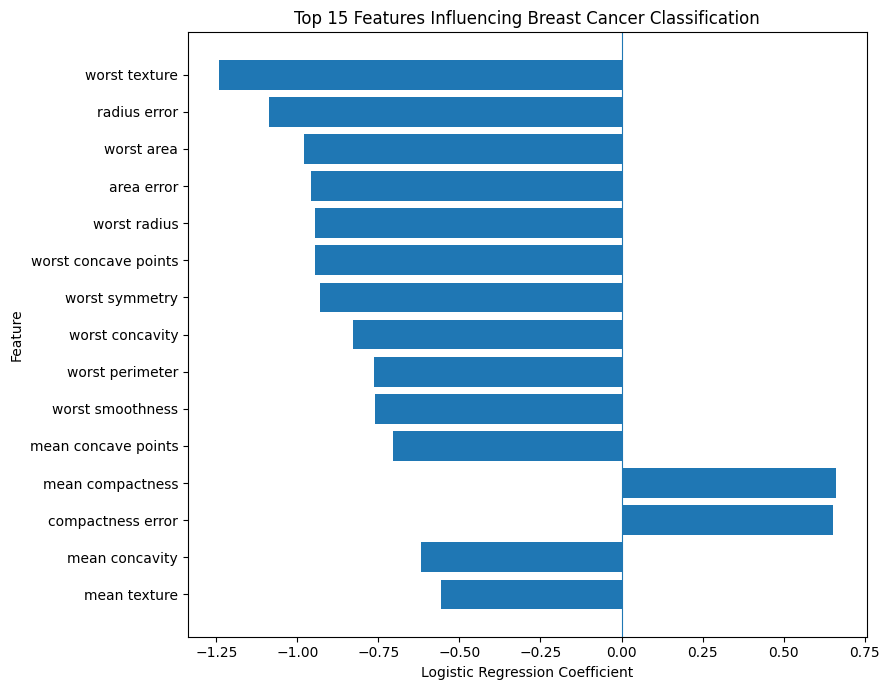

In [14]:
import matplotlib.pyplot as plt

top_features = feature_importance.head(15).sort_values(
    'Absolute_Importance'
)

plt.figure(figsize=(9, 7))

plt.barh(
    top_features['Feature'],
    top_features['Coefficient']
)

plt.axvline(0, linewidth=0.8)
plt.xlabel("Logistic Regression Coefficient")
plt.ylabel("Feature")
plt.title("Top 15 Features Influencing Breast Cancer Classification")

plt.tight_layout()
plt.show()

In [15]:
import os
import joblib
import json

# Create models directory
os.makedirs("models", exist_ok=True)

# Save final model pipeline
joblib.dump(
    final_model,
    "models/final_logistic_regression.pkl"
)

# Save final model information
final_results = {
    "model": "Logistic Regression",
    "best_parameters": logreg_grid.best_params_,
    "cv_roc_auc": round(logreg_grid.best_score_, 4),
    "test_accuracy": round(accuracy, 4),
    "test_precision": round(precision, 4),
    "test_recall": round(recall, 4),
    "test_f1": round(f1, 4),
    "test_roc_auc": round(roc_auc, 4),
    "confusion_matrix": confusion_matrix(y_test, y_pred).tolist()
}

with open("models/final_model_results.json", "w") as f:
    json.dump(final_results, f, indent=4)

print("Final model saved successfully.")
print("File: models/final_logistic_regression.pkl")
print("Results: models/final_model_results.json")

Final model saved successfully.
File: models/final_logistic_regression.pkl
Results: models/final_model_results.json


In [16]:
# Save feature importance results
os.makedirs("data", exist_ok=True)

feature_importance.to_csv(
    "data/final_feature_importance.csv",
    index=False
)

print("Feature importance saved successfully.")
print("File: data/final_feature_importance.csv")

Feature importance saved successfully.
File: data/final_feature_importance.csv


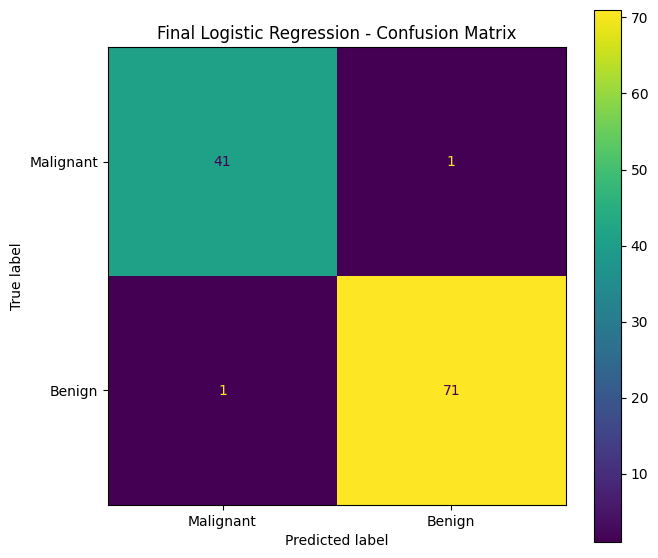

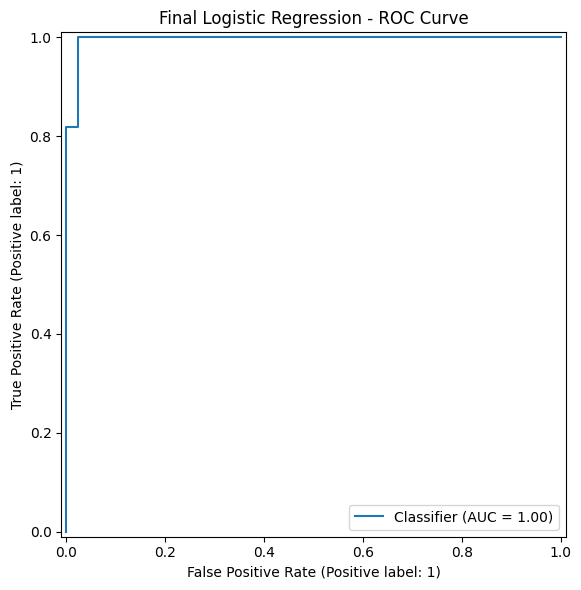

Plots saved successfully.
1. results/confusion_matrix.png
2. results/roc_curve.png


In [17]:
import os
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay

os.makedirs("results", exist_ok=True)

# -------------------------
# Confusion Matrix
# -------------------------
fig, ax = plt.subplots(figsize=(7, 6))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["Malignant", "Benign"],
    ax=ax
)

ax.set_title("Final Logistic Regression - Confusion Matrix")
fig.tight_layout()

fig.savefig(
    "results/confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close(fig)


# -------------------------
# ROC Curve
# -------------------------
fig, ax = plt.subplots(figsize=(7, 6))

RocCurveDisplay.from_predictions(
    y_test,
    y_prob,
    ax=ax
)

ax.set_title("Final Logistic Regression - ROC Curve")
fig.tight_layout()

fig.savefig(
    "results/roc_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close(fig)

print("Plots saved successfully.")
print("1. results/confusion_matrix.png")
print("2. results/roc_curve.png")

## 🧬 Final Project Conclusion

This project developed an end-to-end **AI/ML pipeline for biological and biomedical data analysis**, combining classical machine learning, deep learning, feature interpretation, and biological sequence analysis.

For the **breast cancer classification component**, the Breast Cancer Wisconsin Diagnostic dataset containing 569 samples and 30 numerical cell-nucleus features was processed through data preprocessing, feature analysis, dimensionality reduction, and machine learning model development. Four classification approaches—**Logistic Regression, Support Vector Machine (SVM), Random Forest, and Artificial Neural Network (ANN)**—were evaluated and optimized using stratified 5-fold cross-validation and hyperparameter tuning.

Among the evaluated models, **Logistic Regression was selected as the final model** based on its strongest cross-validation performance. It achieved a **cross-validation ROC-AUC of 0.9960** and, on the independent test set, achieved **98.25% accuracy, 98.61% precision, 98.61% recall, 98.61% F1-score, and 0.9957 ROC-AUC**. The confusion matrix showed only two misclassified samples out of 114 test samples, demonstrating strong predictive performance on this dataset.

Feature interpretation using standardized Logistic Regression coefficients identified features such as **worst texture, radius error, worst area, area error, worst radius, and worst concave points** among the features with the greatest influence on the model's classification decisions. These results demonstrate how machine learning can be combined with feature-level interpretation to identify biologically relevant patterns in structured biomedical data.

As an additional biological sequence analysis component, an **LSTM-based recurrent neural network** was developed to classify 40-base-pair DNA sequences containing promoter-like motifs. The sequence model achieved approximately **91.25% test accuracy**, demonstrating the application of deep learning to raw biological sequence data.

Overall, the project demonstrates an end-to-end workflow covering:

**Data preprocessing → Exploratory Analysis → Feature Selection → PCA → Model Development → Hyperparameter Tuning → Cross-Validation → Independent Test Evaluation → Feature Interpretation → Biological Sequence Modeling**

The project provides practical experience in applying **AI/ML methods to biomedical and bioinformatics problems**, while emphasizing reproducible analysis, model evaluation, and biological interpretation. The workflow can be extended in future research using real-world datasets such as **TCGA or GEO gene-expression data**, explainable AI methods such as **SHAP/LIME**, and advanced sequence models such as **transformer-based architectures**.

### Research & Development Perspective

The project demonstrates how computational approaches can support early-stage **biomarker analysis, biological data exploration, predictive modeling, and hypothesis generation** in an R&D environment. However, the breast cancer classification model is intended for **educational and research purposes** and has not been clinically validated for diagnostic use.

### Final Outcome

The completed project successfully integrates **classical machine learning, deep learning, bioinformatics concepts, model optimization, statistical evaluation, and biological interpretation** into a single reproducible AI/ML workflow.
